#**<font color='green'>ETAPA 4: PREPARAR LOS DATOS**

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
#from sklearn.compose import ColumnTransformer
#from sklearn.pipeline import Pipeline


bold  = "\033[1m"
under = "\033[4m"
reset = "\033[0m"

In [2]:
#cargamos los datos tras el EDA
diabetes=pd.read_csv('../data/processed/diabetes_postEDA.csv')
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 735 entries, 0 to 734
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               735 non-null    int64  
 1   Glucose                   735 non-null    int64  
 2   BloodPressure             735 non-null    int64  
 3   SkinThickness             735 non-null    int64  
 4   Insulin                   735 non-null    int64  
 5   BMI                       735 non-null    float64
 6   DiabetesPedigreeFunction  735 non-null    float64
 7   Age                       735 non-null    int64  
 8   Outcome                   735 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 51.8 KB


Antes de empezar a realizar los cambios, vamos a crear un pequeño DataFrame donde quede constancia de los cambios aplicados a cada variable para después, facilmente, poder ver todos los cambios reallizados en el archivo.

Para ello, creo una funcion **log_registro** donde le pasaré diferentes detalles de la accíon realizada.

In [3]:
flecha="\u2192"

#dataframe que registra los cambios de cada variable (hará el log)
log_diabetes = pd.DataFrame(columns=['DataSet', 'Variable', 'Problema', 'Accion', 'Detalle', 'LineasAfectadas', 'Pipeline?'])

#creo la función que guardará cada registro
def log_registro (dataset, variable, problema, accion, detalle, lineasafectadas, pipeline):
  global log_diabetes    #permite que use el log_diabetes general y no intente crear uno nuevo dentro de la función
  log_diabetes.loc[len(log_diabetes)]=[dataset, variable, problema, accion, detalle, lineasafectadas, pipeline]


In [4]:
#indicamos punto de partida en el archivo log
log_registro ('Inicial', 'Todas', 'Apertura', 'Apertura', '735 observaciones; 9 columnas','Todas', 'No')

##**<font color='green'>4.1. Features (X) vs Target (y)**

In [5]:
#separamos los datos de todas las caracteristicas excepto la variable 'Outcome'
#(que es lo que querremos predecir) en X, y la variable 'Outcome' en y

X=diabetes.drop(columns=['Outcome'])
y=diabetes['Outcome']
print('Separadas las caracteristicas del objetivo. Creadas X e y!')
log_registro ('X-y', 'Todas', 'Split X-y', 'Split X-y', 'Creacion X-y','Todas', 'No')



Separadas las caracteristicas del objetivo. Creadas X e y!


##**<font color='green'>4.2. Train - Test Split**

In [6]:
#dividimos nuestros datos en datos para el entreno y datos para el testeo
#tomaremos 80% de los datos para entrenar y el 20% de los datos para testear.

X_train, X_test, y_train, y_test = train_test_split (X, y,
                                                     test_size = 0.2, random_state=42,
                                                     stratify=y) #mantiene la proporcion de la y en todas las muestras
print('Observaciones en X_train: ', len(X_train))
print('Observaciones en y_train: ', len(y_train))
print('\nObservaciones en X_test: ', len(X_test))
print('Observaciones en y_test: ', len(y_test))


log_registro ('X_train', 'Todas exc. y', 'Train-Test Split', 'Creacion X_train', 'Train-Test Split', len(X_train), 'No')
log_registro ('X_test', 'Todas exc. y', 'Train-Test Split', 'Creacion X_test', 'Train-Test Split', len(X_test), 'No')
log_registro ('y_train', 'y', 'Train-Test Split', 'Creacion y_train', 'Train-Test Split', len(y_train), 'No')
log_registro ('y_test', 'y', 'Train-Test Split', 'Creacion y_test', 'Train-Test Split', len(y_test), 'No')


Observaciones en X_train:  588
Observaciones en y_train:  588

Observaciones en X_test:  147
Observaciones en y_test:  147


##**<font color='green'>4.3. Lista de columnas numéricas**

In [7]:
num_col = [col for col in X_train.columns]
print(num_col)


['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


##**<font color='green'>4.4. Missing Values**

Como se vio en el EDA, en esta base de datos no hay "Missing Values", pero sí que hay varias variables que toman valores 0 cuando en realidad no es posible que esas variables tomen ese valor. Por tanto, esos ceros los consideraremos como Valores Misising.

Las 5 variables que veremos son: **Glucose**, **BloodPressure (BP)**, **SkinThickness (ST)**, **Insulin** y **BMI**.


### **<font color='green'>4.4.1. Glucose**

>Veamos si en nuestra muestra de entrenamiento tenemos algun cero en GLUCOSE de los 5 que habiamos detectado en el EDA y si lo hay, eliminamos o imputamos? No seran muchas lineas, pero veamos primero que información eliminaríamos si las quitaramos:

In [8]:
#visualizamos las lineas con valor en GLUCOSE=0
X_train[X_train['Glucose']==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
328,1,0,68,35,0,32.0,0.389,22
334,5,0,80,32,0,41.0,0.346,37
71,1,0,48,20,0,24.7,0.140,22
480,6,0,68,41,0,39.0,0.727,41
176,1,0,74,20,23,27.7,0.299,21


>Las 5 observaciones con Glucose = 0 estan en la muestra de entrenamiento. Son pocas y podríamos eliminarlas, pero justo contienen información de la  variable SKINTHICKNESS, que es una de las que tenía casi 200 valores missing, así que mejor imputaremos algun valor a Glucose para no perder más información.

>Dado que vimos que la distribución de GLUCOSE se asemejaba bastante a una distribución normal, la mediana y la media no seran muy diferentes, por lo que tomaremos la **mediana** en este caso para realizar el SimpleImputer ya que el valor es un entero, como los valores iniciales y así no es necesario modificar el tipo de variable además que es menos influenciable por los outliers.


In [9]:
#Con SimpleImputer sustituimos valores 0 de GLUCOSE por la mediana de X_train
#y mantenemos variable entera

#creamos mascara para los casos que cumplen Glucose=0 y los marcamos en el set de datos
#con la variable flag_Glucose_mis para identificar las lineas modificadas
mask_tra_Glucose_mis = X_train['Glucose']==0
mask_tes_Glucose_mis = X_test['Glucose']==0

X_train['flag_mis_Glucose']=mask_tra_Glucose_mis.astype(int)
X_test['flag_mis_Glucose']=mask_tes_Glucose_mis.astype(int)

print('Ceros de GLUCOSE (X_train) ANTES: ', X_train['flag_mis_Glucose'].sum())
print('Ceros de GLUCOSE (X_test) ANTES: ', X_test['flag_mis_Glucose'].sum())

imp_Glucose = SimpleImputer (missing_values = 0, strategy = 'median')

#ajustamos
imp_Glucose.fit(X_train[['Glucose']])

#transformamos
X_train['Glucose'] = imp_Glucose.transform(X_train[['Glucose']])
X_test['Glucose'] = imp_Glucose.transform(X_test[['Glucose']])

print('\nCeros de GLUCOSE (X_train) DESPUES: ', len(X_train[(X_train['Glucose']==0)]))
print('Ceros de GLUCOSE (X_test) DESPUES: ', len(X_test[(X_test['Glucose']==0)]))

Ceros de GLUCOSE (X_train) ANTES:  5
Ceros de GLUCOSE (X_test) ANTES:  0

Ceros de GLUCOSE (X_train) DESPUES:  0
Ceros de GLUCOSE (X_test) DESPUES:  0


>Tal y como estaba previsto, he sustituido los valores 0 de la variable GLUCOSE con la **mediana** de GLUCOSE sin tener en cuenta los valores con valor 0, por ser en realidad falta de información.

>Una vez realizado el proceso, registro la modificación en el log_df, para que quede constancia de ello:

In [10]:
log_registro('X_train', 'Glucose','Missing values', 'Imputacion', f'0 {flecha} mediana de X_train', 5, 'Si')
log_registro('X_test', 'Glucose','Missing values', 'Imputacion', f'0 {flecha} mediana de X_train', 0, 'Si')
log_registro('X_train', 'flag_mis_Glucose','Missing values', 'Creacion variable control', 'Creacion flag_mis', 'Todas', 'Si')
log_registro('X_test', 'flag_mis_Glucose','Missing values', 'Creacion variable control', 'Creacion flag_mis', 'Todas', 'Si')
log_diabetes

,DataSet,Variable,Problema,Accion,Detalle,LineasAfectadas,Pipeline?
0,Inicial,Todas,Apertura,Apertura,735 observaciones; 9 columnas,Todas,No
1,X-y,Todas,Split X-y,Split X-y,Creacion X-y,Todas,No
2,X_train,Todas exc. y,Train-Test Split,Creacion X_train,Train-Test Split,588,No
3,X_test,Todas exc. y,Train-Test Split,Creacion X_test,Train-Test Split,147,No
4,y_train,y,Train-Test Split,Creacion y_train,Train-Test Split,588,No
5,y_test,y,Train-Test Split,Creacion y_test,Train-Test Split,147,No
6,X_train,Glucose,Missing values,Imputacion,0 → mediana de X_train,5,Si
7,X_test,Glucose,Missing values,Imputacion,0 → mediana de X_train,0,Si
8,X_train,flag_mis_Glucose,Missing values,Creacion variable control,Creacion flag_mis,Todas,Si
9,X_test,flag_mis_Glucose,Missing values,Creacion variable control,Creacion flag_mis,Todas,Si


### **<font color='green'>4.4.2. BloodPressure**

>En el EDA no vimos ningun patrón para estos missing, parecian errores aleatorios. Veamos primero cuantos hay, y despúes realizaremos la imputación de la mediana. **Mediana**, como en el caso anterior, ya que también tienen una distribución muy parecida a la normal y deberian ser prácticamnete iguales y asi mantenemos los numeros enteros y sin tener mucha influencia de posibles outliers.

In [11]:
#Con SimpleImputer sustituimos valores 0 de BLOODPRESSURE por la mediana de X_train
#y mantenemos variable entera

#creamos mascara para los casos que cumplen BloodPressure=0 y los marcamos en el set de datos
#con la variable flag_BP_mis para identificar las lineas modificadas
mask_tra_BP_mis = X_train['BloodPressure']==0
mask_tes_BP_mis = X_test['BloodPressure']==0

X_train['flag_mis_BloodPressure']=mask_tra_BP_mis.astype(int)
X_test['flag_mis_BloodPressure']=mask_tes_BP_mis.astype(int)

print('Ceros de BLOODPRESSURE (X_train) ANTES: ', X_train['flag_mis_BloodPressure'].sum())
print('Ceros de BLOODPRESSURE (X_test) ANTES: ', X_test['flag_mis_BloodPressure'].sum())

imp_BloodPressure = SimpleImputer (missing_values = 0, strategy = 'median')

#ajustamos
imp_BloodPressure.fit(X_train[['BloodPressure']])

#transformamos
X_train['BloodPressure'] = imp_BloodPressure.transform(X_train[['BloodPressure']])
X_test['BloodPressure'] = imp_BloodPressure.transform(X_test[['BloodPressure']])

print('\nCeros de BLOODPRESSURE (X_train) DESPUES: ', len(X_train[(X_train['BloodPressure']==0)]))
print('Ceros de BLOODPRESSURE (X_test) DESPUES: ', len(X_test[(X_test['BloodPressure']==0)]))

Ceros de BLOODPRESSURE (X_train) ANTES:  2
Ceros de BLOODPRESSURE (X_test) ANTES:  0

Ceros de BLOODPRESSURE (X_train) DESPUES:  0
Ceros de BLOODPRESSURE (X_test) DESPUES:  0


>Hemos comprobado que los cambios se han hecho correctamente.  Se registra el cambio en el log.

In [12]:
#registramos el cambios en el log
log_registro('X_train', 'BloodPressure','Missing values', 'Imputacion', f'0 {flecha} mediana de X_train', 2, 'Si')
log_registro('X_test', 'BloodPressure','Missing values', 'Imputacion', f'0 {flecha} mediana de X_train', 0, 'Si')
log_registro('X_train', 'flag_mis_BloodPressure','Missing values', 'Creacion variable control', 'Creacion flag_mis',  'Todas', 'Si')
log_registro('X_test', 'flag_mis_BloodPressure','Missing values', 'Creacion variable control', 'Creacion flag_mis', 'Todas', 'Si')
print('¡Registradas las nuevas modificaciones!')

¡Registradas las nuevas modificaciones!


### **<font color='green'>4.4.3. SkinThickness**
>En esta variable teníamos muchos missing values. Como en los casos anteriores, imputaremos la **mediana** a esos 0's, ya que al calcular la kurtosis sin los 0, obteniamos que aumentaban bastante el valor, por lo que aumentaba el número de outliers, y tambien skewness, sin los 0's, tenia más sesgo a la derecha, por lo que la media se puede ver afectada por los outliers.

In [13]:
#Con SimpleImputer sustituimos valores 0 de SKINTHICKNESS por la mediana de X_train
#y mantenemos variable entera

#creamos mascara para los casos que cumplen BloodPressure=0 y los marcamos en el set de datos
#con la variable flag_BP_mis para identificar las lineas modificadas
mask_tra_ST_mis = X_train['SkinThickness']==0
mask_tes_ST_mis = X_test['SkinThickness']==0

X_train['flag_mis_SkinThickness']=mask_tra_ST_mis.astype(int)
X_test['flag_mis_SkinThickness']=mask_tes_ST_mis.astype(int)

print('Ceros de SKINTHICKNESS (X_train) ANTES: ', X_train['flag_mis_SkinThickness'].sum())
print('Ceros de SKINTHICKNESS (X_test) ANTES: ', X_test['flag_mis_SkinThickness'].sum())

imp_SkinThickness = SimpleImputer (missing_values = 0, strategy = 'median')

#ajustamos
imp_SkinThickness.fit(X_train[['SkinThickness']])

#transformamos
X_train['SkinThickness'] = imp_SkinThickness.transform(X_train[['SkinThickness']])
X_test['SkinThickness'] = imp_SkinThickness.transform(X_test[['SkinThickness']])

print('\nCeros de SKINTHICKNESS (X_train) DESPUES: ', len(X_train[(X_train['SkinThickness']==0)]))
print('Ceros de SKINTHICKNESS (X_test) DESPUES: ', len(X_test[(X_test['SkinThickness']==0)]))

Ceros de SKINTHICKNESS (X_train) ANTES:  159
Ceros de SKINTHICKNESS (X_test) ANTES:  35

Ceros de SKINTHICKNESS (X_train) DESPUES:  0
Ceros de SKINTHICKNESS (X_test) DESPUES:  0


In [14]:
#registramos el cambio
log_registro('X_train', 'SkinThickness','Missing values', 'Imputacion', f'0 {flecha} mediana de X_train', 159, 'Si')
log_registro('X_test', 'SkinThickness','Missing values', 'Imputacion', f'0 {flecha} mediana de X_train', 35, 'Si')
log_registro('X_train', 'flag_mis_ST','Missing values', 'Creacion variable control', 'Creacion flag_mis', 'Todas', 'Si')
log_registro('X_test', 'flag_mis_ST','Missing values', 'Creacion variable control', 'Creacion flag_mis',  'Todas', 'Si')

print('¡Registradas las nuevas modificaciones!')

¡Registradas las nuevas modificaciones!


### **<font color='green'>4.4.4. Insulin**
>Previamente a revisar los Missings de esta variable, vamos a crear una nueva variable, Insulin2, que contendrá los valores de Insulin, excepto para los valores outliers de la parte mas alta, ya que supondremos que esos valores estan tomados con una escala erronea y realizaremos un cambio de unidades para esos valores: 1 uU/ml = 7.175 pmol/L



In [15]:
#veamos cuales son los outliers de Insulin mediante el metodo IQR
#y los transformaremos segun la equivalencia 1 uU/ml = 7.175 pmol/L
Q1 = X_train[(X_train['Insulin']!=0)]['Insulin'].quantile(0.25)
Q3 = X_train[(X_train['Insulin']!=0)]['Insulin'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print('El número de Outliers que tenemos por la parte alta de Insulin en X_train son:', len(X_train[(X_train['Insulin']>upper)]))
print('El número de Outliers que tenemos por la parte alta de Insulin en X_test son:', len(X_test[(X_test['Insulin']>upper)]))

#creamos la mascara que nos marcará las lineas con los outliers altos
mask_tra_Insulin_out_top=X_train['Insulin']>upper
mask_tes_Insulin_out_top=X_test['Insulin']>upper

#Creamos la variable Insulin2, donde los valores superiores a UPPER los transforma
#según la equivalencia, X_train y X_test (1 uU/ml = 7.175 pmol/L)
factor= 1/7.175
X_train['Insulin2']=np.where(X_train['Insulin']>upper, X_train['Insulin']*factor, X_train['Insulin'])
X_train['flag_outl_Insulin2']=mask_tra_Insulin_out_top.astype(int)

X_test['Insulin2']=np.where(X_test['Insulin']>upper, X_test['Insulin']*factor, X_test['Insulin'])
X_test['flag_outl_Insulin2']=mask_tes_Insulin_out_top.astype(int)

log_registro ('X_train', 'Insulin2', 'Outliers con errores', 'Creacion variable', f'Insulin {flecha} Outliers altos divididos por 7.175', 'Todas', 'Si')
log_registro ('X_test', 'Insulin2', 'Outliers con errores', 'Creacion variable', f'Insulin {flecha} Outliers altos divididos por 7.175', 'Todas', 'Si')
log_registro('X_train', 'flag_outl_Insulin2','Outliers', 'Creacion variable control', 'Creacion flag recalculados', 'Todas', 'Si')
log_registro('X_test', 'flag_outl_Insulin2','Outliers', 'Creacion variable control', 'Creacion flag recalculados', 'Todas', 'Si')

El número de Outliers que tenemos por la parte alta de Insulin en X_train son: 22
El número de Outliers que tenemos por la parte alta de Insulin en X_test son: 2


>Esta variable tenía 341 observaciones con valor 0. Por construcción, Insulin2 tendrá los mismos valores 0. En este caso, tambien definimos los valores 0 como missing y vamos a cambiar los 0 por el valor de la mediana, siguiendo exactamente los mismos pasos en Insulin e Insulin 2, pero cada una con su propia mediana, que seguramente será bastante diferente

In [16]:
#Con SimpleImputer sustituimos valores 0 de INSULIN por la mediana de X_train
#y mantenemos variable entera

#creamos mascara para los casos que cumplen INSULIN=0 y los marcamos en el set de datos
#con la variable flag_Insulin_mis para identificar las lineas modificadas
mask_tra_Insulin_mis = X_train['Insulin']==0
mask_tes_Insulin_mis = X_test['Insulin']==0

X_train['flag_mis_Insulin']=mask_tra_Insulin_mis.astype(int)
X_test['flag_mis_Insulin']=mask_tes_Insulin_mis.astype(int)

print('Ceros de INSULIN (X_train) ANTES: ', X_train['flag_mis_Insulin'].sum())
print('Ceros de INSULIN (X_test) ANTES: ', X_test['flag_mis_Insulin'].sum())

imp_Insulin = SimpleImputer (missing_values = 0, strategy = 'median')

#ajustamos
imp_Insulin.fit(X_train[['Insulin']])

#transformamos
X_train['Insulin'] = imp_Insulin.transform(X_train[['Insulin']])
X_test['Insulin'] = imp_Insulin.transform(X_test[['Insulin']])

print('\nCeros de INSULIN (X_train) DESPUES: ', len(X_train[(X_train['Insulin']==0)]))
print('Ceros de INSULIN (X_test) DESPUES: ', len(X_test[(X_test['Insulin']==0)]))

Ceros de INSULIN (X_train) ANTES:  275
Ceros de INSULIN (X_test) ANTES:  66

Ceros de INSULIN (X_train) DESPUES:  0
Ceros de INSULIN (X_test) DESPUES:  0


In [17]:
#registramos el cambio
log_registro('X_train', 'Insulin','Missing values', 'Imputacion', f'0 {flecha} mediana de X_train', 275, 'Si')
log_registro('X_test', 'insulin','Missing values', 'Imputacion', f'0 {flecha} mediana de X_train', 66, 'Si')
log_registro('X_train', 'flag_mis_Insulin','Missing values', 'Creacion variable control', 'Creacion flag_mis', 'Todas', 'Si')
log_registro('X_test', 'flag_mis_Insulin','Missing values', 'Creacion variable control', 'Creacion flag_mis', 'Todas', 'Si')

print('¡Registradas las nuevas modificaciones!')

¡Registradas las nuevas modificaciones!


In [18]:
#Con SimpleImputer sustituimos valores 0 de INSULIN2 por la mediana de X_train
#y mantenemos variable entera

#creamos mascara para los casos que cumplen INSULIN2=0 y los marcamos en el set de datos
#con la variable flag_Insulin2_mis para identificar las lineas modificadas
mask_tra_Insulin2_mis = X_train['Insulin2']==0
mask_tes_Insulin2_mis = X_test['Insulin2']==0

X_train['flag_mis_Insulin2']=mask_tra_Insulin2_mis.astype(int)
X_test['flag_mis_Insulin2']=mask_tes_Insulin2_mis.astype(int)

print('Ceros de INSULIN2 (X_train) ANTES: ', X_train['flag_mis_Insulin2'].sum())
print('Ceros de INSULIN2 (X_test) ANTES: ', X_test['flag_mis_Insulin2'].sum())

imp_Insulin2 = SimpleImputer (missing_values = 0, strategy = 'median')

#ajustamos
imp_Insulin2.fit(X_train[['Insulin2']])

#transformamos
X_train['Insulin2'] = imp_Insulin2.transform(X_train[['Insulin2']])
X_test['Insulin2'] = imp_Insulin2.transform(X_test[['Insulin2']])

print('\nCeros de INSULIN2 (X_train) DESPUES: ', len(X_train[(X_train['Insulin2']==0)]))
print('Ceros de INSULIN2 (X_test) DESPUES: ', len(X_test[(X_test['Insulin2']==0)]))

Ceros de INSULIN2 (X_train) ANTES:  275
Ceros de INSULIN2 (X_test) ANTES:  66

Ceros de INSULIN2 (X_train) DESPUES:  0
Ceros de INSULIN2 (X_test) DESPUES:  0


In [19]:
#registramos el cambio
log_registro('X_train', 'Insulin2','Missing values', 'Imputacion', f'0 {flecha} mediana de X_train', 275, 'Si')
log_registro('X_test', 'insulin2','Missing values', 'Imputacion', f'0 {flecha} mediana de X_train', 66, 'Si')
log_registro('X_train', 'flag_mis_Insulin2','Missing values', 'Creacion variable control', 'Creacion flag_mis', 'Todas', 'Si')
log_registro('X_test', 'flag_mis_Insulin2','Missing values', 'Creacion variable control', 'Creacion flag_mis', 'Todas', 'Si')

print('¡Registradas las nuevas modificaciones!')

¡Registradas las nuevas modificaciones!


In [20]:
#vemos los descriptivos de Insulin e Insulin2 en X_train
X_train[['Insulin', 'Insulin2']].describe()

,Insulin,Insulin2
count,588.000000,588.000000
mean,143.547619,121.350737
std,92.987915,54.175563
min,14.000000,14.000000
25%,120.000000,105.750000
50%,126.000000,114.000000
75%,130.000000,119.250000
max,846.000000,360.000000


### **<font color='green'>4.4.5. BMI**
>En esta variable nos encontramos en todo el data set 4 casos con valor 0, los cuales tambien los consideramos como missing values (de tomar el valor 0, implicaria que el peso de la persona es 0 kg). Veamos que contienen esas lineas en X_train y si es posible eliminarlas o mejor es imputar la mediana como en el resto de casos.

In [21]:
#veamos que lineas tienen BMI=0 en X_train
X_train[(X_train['BMI']==0)]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,flag_mis_Glucose,flag_mis_BloodPressure,flag_mis_SkinThickness,Insulin2,flag_outl_Insulin2,flag_mis_Insulin,flag_mis_Insulin2
356,0,118.0,64.0,23.0,89.0,0.0,1.731,21,0,0,0,89.0,0,0,0
654,5,136.0,82.0,29.0,126.0,0.0,0.640,69,0,0,1,114.0,0,1,1
8,8,125.0,96.0,29.0,126.0,0.0,0.232,54,0,0,1,114.0,0,1,1


>Las 3 lineas que tienen BMI=0 en X_train, tienen valores válidos tanto en SkinThickness como en Insulin, que son las que tenían mas missings, por tanto, no las podemos eliminar e imputaremos esos valores de BMI con la mediana.

In [22]:
#Con SimpleImputer sustituimos valores 0 de BMI por la mediana de X_train

#creamos mascara para los casos que cumplen BMI=0 y los marcamos en el set de datos
#con la variable flag_BMI_mis para identificar las lineas modificadas
mask_tra_BMI_mis = X_train['BMI']==0
mask_tes_BMI_mis = X_test['BMI']==0

X_train['flag_mis_BMI']=mask_tra_BMI_mis.astype(int)
X_test['flag_mis_BMI']=mask_tes_BMI_mis.astype(int)

print('Ceros de BMI (X_train) ANTES: ', X_train['flag_mis_BMI'].sum())
print('Ceros de BMI (X_test) ANTES: ', X_test['flag_mis_BMI'].sum())

imp_BMI = SimpleImputer (missing_values = 0, strategy = 'median')

#ajustamos
imp_BMI.fit(X_train[['BMI']])

#transformamos
X_train['BMI'] = imp_BMI.transform(X_train[['BMI']])
X_test['BMI'] = imp_BMI.transform(X_test[['BMI']])

print('\nCeros de BMI (X_train) DESPUES: ', len(X_train[(X_train['BMI']==0)]))
print('Ceros de BMI (X_test) DESPUES: ', len(X_test[(X_test['BMI']==0)]))

Ceros de BMI (X_train) ANTES:  3
Ceros de BMI (X_test) ANTES:  1

Ceros de BMI (X_train) DESPUES:  0
Ceros de BMI (X_test) DESPUES:  0


In [23]:
#registramos el cambio
log_registro('X_train', 'BMI','Missing values', 'Imputacion', f'0 {flecha} mediana de X_train', 3, 'Si')
log_registro('X_test', 'BMI','Missing values', 'Imputacion', f'0 {flecha} mediana de X_train', 1, 'Si')
log_registro('X_train', 'flag_mis_BMI','Missing values', 'Creacion variable control', 'Creacion flag_mis', 'Todas', 'Si')
log_registro('X_test', 'flag_mis_BMI','Missing values', 'Creacion variable control', 'Creacion flag_mis', 'Todas', 'Si')

print('¡Registradas las nuevas modificaciones!')

log_diabetes

¡Registradas las nuevas modificaciones!


,DataSet,Variable,Problema,Accion,Detalle,LineasAfectadas,Pipeline?
0,Inicial,Todas,Apertura,Apertura,735 observaciones; 9 columnas,Todas,No
1,X-y,Todas,Split X-y,Split X-y,Creacion X-y,Todas,No
2,X_train,Todas exc. y,Train-Test Split,Creacion X_train,Train-Test Split,588,No
3,X_test,Todas exc. y,Train-Test Split,Creacion X_test,Train-Test Split,147,No
4,y_train,y,Train-Test Split,Creacion y_train,Train-Test Split,588,No
5,y_test,y,Train-Test Split,Creacion y_test,Train-Test Split,147,No
6,X_train,Glucose,Missing values,Imputacion,0 → mediana de X_train,5,Si
7,X_test,Glucose,Missing values,Imputacion,0 → mediana de X_train,0,Si
8,X_train,flag_mis_Glucose,Missing values,Creacion variable control,Creacion flag_mis,Todas,Si
9,X_test,flag_mis_Glucose,Missing values,Creacion variable control,Creacion flag_mis,Todas,Si


In [24]:
#comprobacion que en las variables tratadas, no quedan 0
print('Mínimos de cada columna de X_train:\n', X_train[num_col].min())
print('\n\nMínimos de cada columna de X_test:\n', X_test[num_col].min())

Mínimos de cada columna de X_train:
 Pregnancies                  0.000
Glucose                     44.000
BloodPressure               24.000
SkinThickness                7.000
Insulin                     14.000
BMI                         18.200
DiabetesPedigreeFunction     0.084
Age                         21.000
dtype: float64


Mínimos de cada columna de X_test:
 Pregnancies                  0.000
Glucose                     71.000
BloodPressure               46.000
SkinThickness                8.000
Insulin                     32.000
BMI                         19.300
DiabetesPedigreeFunction     0.078
Age                         21.000
dtype: float64


##**<font color='green'>4.5. Outliers**

Vamos a localizar los Outliers de todas las variables numéricas que encontramos en X_train:


In [25]:
#determinación de outliers con el metodo IQR
def loc_outliers_iqr(df, columns_list):
    outlier_summary = {}
    for columna in columns_list:
        Q1=df[columna].quantile(0.25)
        Q3=df[columna].quantile(0.75)
        IQR = Q3 - Q1
        lower=Q1 - 1.5*IQR
        upper=Q3 + 1.5*IQR
        mask = (df[columna]<lower) | (df[columna]>upper)
        outlier_summary[columna] = {'n_outliers': mask.sum(), '%_outliers': round(mask.mean()*100, 2),
                                    'limites': (round(lower, 2), round(upper, 2))}
    outlier_summary =pd.DataFrame(outlier_summary).T
    return outlier_summary

num_col.append('Insulin2')

outliers_train = loc_outliers_iqr(X_train, num_col)

print(f'{bold}Lineas de X_train{reset}: ', len(X_train))
print(f'\n{bold}RESUMEN OUTLIERS X_train{reset}:\n\n', outliers_train)

Lineas de X_train:  588

RESUMEN OUTLIERS X_train:

                          n_outliers %_outliers         limites
Pregnancies                       3       0.51    (-6.5, 13.5)
Glucose                           0        0.0   (34.5, 206.5)
BloodPressure                    13       2.21   (40.0, 104.0)
SkinThickness                    34       5.78    (13.0, 45.0)
Insulin                         240      40.82  (105.0, 145.0)
BMI                               5       0.85  (13.35, 50.55)
DiabetesPedigreeFunction         23       3.91   (-0.35, 1.23)
Age                               8       1.36    (-1.5, 66.5)
Insulin2                        219      37.24   (85.5, 139.5)


Vemos que todas las variables en X_train presentan algun Outlier, excepto Glucose. Veamos cada caso, a ver como es mejor actuar:
* **Pregnancies**: Encontramos 3 casos, pero en una población donde hay varias mujeres que han tenido más de 10 embarazos, llegar a los 17 embarazos, no sería tan raro. Además, son embarazos, que no hijos. Vamos a **dejarlos igual**, sin más.

* **BloodPressure**: En este caso, lo que sabemos es que lo normal es estar por debajo de 80, a partir de ahi, es alto, por lo que trataremos los outliers con **winsorización** (**PROBAR CON KNNIMPUTER?** en caso de buscar mejorías)

* **SkinThickness**:Con esta variable aplicaremos también una **winsorización**(**PROBAR CON KNNIMPUTER?** en caso de buscar mejorías)

* **Insulin**: En este caso, si que hay muchos outliers y la distribucion presenta un sesgo a la derecha. En este caso, podríamos aplicar tambien una **winsorización** (**PROBAR CON KNNIMPUTER?** - en caso de buscar mejorías-**Y RAIZ CUADRADA/O TRANSFORMACIÓN LOGARÍTMICA DE LA FUNCIÓN?**)

* **BMI**: Tan solo son 5 casos y además en el EDA también vimos que el valor mayor era de 68, que podria cumplirlo alguien que pesara 150kg en 1,6m. No es muy habitual, pero dado que la mayoria de las mujeres de la muestra padecen obesidad o sobrepeso, podría darse el caso. Por tanto, **dejaremos igual esos valores**.

* **DiabetesPedigreeFunction**: Estos datos pertenecen a una función que desconocemos los valores que puede llegar a tomar, aunque no suele ser mas de 2 o 3 unidades. Vamos a aplicarle también **winsorización**, aunque habría que plantearse la opción de **no tocarlos** puesto que al final cuanto mas elevado es este valor, mayor es la predisposición a tener diabetes.

* **Age**: Los valores que toma esta variable, pueden tomarse perfectamente por las entrevistadas y además son pocos casos, por lo que vamos a **dejarlo igual**

* **Insulin2**: Practicamente tienelos mismos outliers que Insulin, por lo que haremos lo mismo. Eso si, esta variable recordemos que los outliers de Insulin, detectados con el metodo IQR, estaban cambiados de unidad, ya que pensabamos que podria ser un error en la toma de medidas. Cuando tengamos en cuenta los modelos, **cuando trabajemos con Insulin no lo haremos con Insulin 2 y a la inversa**.

Por tanto, crearemos nuevas variables aplicando las transformaciones siguientes:
* **Variables que mantienen los outliers iguales en todos los casos**: Pregnancies, BMI y Age
* CASO 1: **Aplicamos Winsorización (capping) --** BlodPressure, SkinThickness, Insulin, DiabetesPedigreeFunction, Insulin2: *BloodPressure_cap*, *SkinThickness_cap*, *Insulin_cap*, *DiabetesPedigreeFunction_cap*, *Insulin2_cap*
* CASO 2:  **Realizamos raiz cuadrada de los valores o una transfromación logarítmica --** Insulin e insulin2: *Añadimos las variables Insulin_Raiz, Insulin_Log, Insulin2_Raiz y Insulin2_Log*
* CASO 3: **Podríamos aplicar KNNImputer --** BloodPressure, SkinThickness, Insulin, Insulin2 y **dejar igual** a DiabetesPedigreeFunction.Veamos más adelante si es necesario realizar esta transformación para mejorar el modelo y quiza habria que plantearse tambien resolver los missing values con KNN y hacerlo todo de golpe. También habría que ver si conviene escalar o no antes de aplicar KNN.






### **<font color='green'>4.5.1. Winsorización**

In [26]:
#WINSORIZACION
#funcion para calcular los limites en la winsorización
def limit_outliers (df, columns_list):
    limit_summary={}
    for columna in columns_list:
        p_1 = df[columna].quantile(0.01)
        p_99 = df[columna].quantile(0.99)
        limit_summary[columna] = {'LimiteInf':p_1, 'LimiteSup':p_99}
    limit_summary = pd.DataFrame(limit_summary)
    return limit_summary

#función para hacer la winsorización con los limites ya dados
def winsor (df, limit_summary, columns_list):
    winsor_summary = {}
    new_var = []
    new_var_flag=[]
    for columna in columns_list:
        mask = (df[columna]<limit_summary.loc['LimiteInf', columna]) | (df[columna]>limit_summary.loc['LimiteSup', columna])
        df[f'flag_outl_{columna}_cap'] = mask.astype(int)

        #.clip asigna a valores <bottom_limit, = bottom_limit y para valores >top_limit, = top_limit
        df[f'{columna}_cap']=np.clip(df[columna],limit_summary.loc['LimiteInf', columna],
        limit_summary.loc['LimiteSup', columna])

        winsor_summary[f'{columna}_cap'] = {'n_winsor': mask.sum(), '%_winsor': round(mask.mean()*100, 2),
                                            'limites':(round(limit_summary.loc['LimiteInf', columna], 2),
                                                       round(limit_summary.loc['LimiteSup', columna], 2))}

        new_var.append(f'{columna}_cap')
        new_var_flag.append(f'flag_outl_{columna}_cap')

    winsor_summary =pd.DataFrame(winsor_summary)

    return df, winsor_summary.T,new_var, new_var_flag

#definimos las variables a las que aplicaremos la winsorización y definimos los limites con X_train
cap_columns = ['BloodPressure', 'SkinThickness', 'Insulin','DiabetesPedigreeFunction','Insulin2']
limits = limit_outliers(X_train, cap_columns)

#aplicamos la transformación de la winsorización a train y test y obtenemos el
#dataframe con los cambios realizados, el resumen de donde se ha aplicado y las nuevas variables creadas
X_train,winsor_train, new_col_tra, new_col_flag_tra = winsor(X_train, limits, cap_columns)
X_test, winsor_test, new_col_tes, new_col_flag_tes = winsor(X_test, limits, cap_columns)


print(f'{under}RESUMEN DE LOS ELEMENTOS WINSORIZADOS EN X_train{reset}:\n', winsor_train)
print(f'\n{under}RESUMEN DE LOS ELEMENTOS WINSORIZADOS EN X_test{reset}:\n', winsor_test)
print(f'\n\n\n{under}MUESTRA DE LAS NUEVAS VARIABLES MOSTRANDO LA WINSORIZACIÓN EN LA VARIABLE BLOODPRESSURE DE X_train{reset}:\n')
X_train[X_train['flag_outl_BloodPressure_cap']==1][new_col_tra].head()

RESUMEN DE LOS ELEMENTOS WINSORIZADOS EN X_train:
                              n_winsor %_winsor          limites
BloodPressure_cap                  11     1.87   (44.0, 106.26)
SkinThickness_cap                  11     1.87    (10.87, 50.0)
Insulin_cap                        12     2.04  (22.87, 543.26)
DiabetesPedigreeFunction_cap       12     2.04     (0.09, 1.74)
Insulin2_cap                       10      1.7   (22.87, 325.0)

RESUMEN DE LOS ELEMENTOS WINSORIZADOS EN X_test:
                              n_winsor %_winsor          limites
BloodPressure_cap                   1     0.68   (44.0, 106.26)
SkinThickness_cap                   7     4.76    (10.87, 50.0)
Insulin_cap                         0      0.0  (22.87, 543.26)
DiabetesPedigreeFunction_cap        1     0.68     (0.09, 1.74)
Insulin2_cap                        2     1.36   (22.87, 325.0)



MUESTRA DE LAS NUEVAS VARIABLES MOSTRANDO LA WINSORIZACIÓN EN LA VARIABLE BLOODPRESSURE DE X_train:



,BloodPressure_cap,SkinThickness_cap,Insulin_cap,DiabetesPedigreeFunction_cap,Insulin2_cap
573,44.00,18.0,120.0,0.407,120.0
119,44.00,42.0,99.0,0.496,99.0
347,106.26,37.0,126.0,0.305,114.0
100,106.26,29.0,126.0,0.207,114.0
78,106.26,29.0,126.0,0.227,114.0


In [27]:
#registro de acciones
for columna in new_col_tra:
    log_registro ('X_train', columna, 'Outliers', 'Creacion variable', f'{columna.split('_')[0]}+ winsorizacion', winsor_train.loc[columna, 'n_winsor'], 'Si' )
    log_registro ('X_test', columna, 'Outliers', 'Creacion variable', f'{columna.split('_')[0]}+ winsorizacion', winsor_test.loc[columna, 'n_winsor'], 'Si' )
for columna in new_col_flag_tra:
    log_registro ('X_train', columna, 'Outliers', 'Creacion variable control', 'Creacion flag_outl', 'Todas', 'Si' )
    log_registro ('X_test', columna, 'Outliers', 'Creacion variable control', 'Creacion flag_outl', 'Todas', 'Si' )

print('Registros realizados!!')
log_diabetes.tail(15)

Registros realizados!!


,DataSet,Variable,Problema,Accion,Detalle,LineasAfectadas,Pipeline?
39,X_test,Insulin_cap,Outliers,Creacion variable,Insulin+ winsorizacion,0,Si
40,X_train,DiabetesPedigreeFunction_cap,Outliers,Creacion variable,DiabetesPedigreeFunction+ winsorizacion,12,Si
41,X_test,DiabetesPedigreeFunction_cap,Outliers,Creacion variable,DiabetesPedigreeFunction+ winsorizacion,1,Si
42,X_train,Insulin2_cap,Outliers,Creacion variable,Insulin2+ winsorizacion,10,Si
43,X_test,Insulin2_cap,Outliers,Creacion variable,Insulin2+ winsorizacion,2,Si
44,X_train,flag_outl_BloodPressure_cap,Outliers,Creacion variable control,Creacion flag_outl,Todas,Si
45,X_test,flag_outl_BloodPressure_cap,Outliers,Creacion variable control,Creacion flag_outl,Todas,Si
46,X_train,flag_outl_SkinThickness_cap,Outliers,Creacion variable control,Creacion flag_outl,Todas,Si
47,X_test,flag_outl_SkinThickness_cap,Outliers,Creacion variable control,Creacion flag_outl,Todas,Si
48,X_train,flag_outl_Insulin_cap,Outliers,Creacion variable control,Creacion flag_outl,Todas,Si


### **<font color='green'>4.5.2. Transformación logarítmica y raíz cuadrada**

In [28]:
#Realizamos raiz cuadrada de los valores o una transformación logarítmica, tanto para
#Insulin como Insulin2. Añadimos las variables Insulin_Raiz, Insulin_Log, Insulin2_Raiz y Insulin2_Log

new_vars=set()

def transformar (df, var_base):
    df[f'{var_base}_Raiz'] = np.sqrt(df[var_base])
    df[f'{var_base}_Log'] = np.log(df[var_base])
    new_vars.update({f'{var_base}_Raiz', f'{var_base}_Log'})
    return df

X_train = transformar(X_train, 'Insulin')
X_train = transformar(X_train, 'Insulin2')
X_test = transformar(X_test, 'Insulin')
X_test = transformar(X_test, 'Insulin2')

new_vars=sorted(list(new_vars))

print('Las nuevas variables para el log son:', new_vars)
print('\n\nMUESTRA DE LAS LINEAS CON LAS NUEVAS VARIABLES:\n', X_train[new_vars].head())


for var in new_vars:
    log_registro('X_train', var, 'Outliers', 'Creacion nueva variable', f'{var.split("_")[1]} de {var.split("_")[0]}','Todas', 'Si')
    log_registro('X_test', var, 'Outliers', 'Creacion nueva variable', f'{var.split("_")[1]} de {var.split("_")[0]}','Todas', 'Si')

print('\n\nNuevos registros realizados en log_diabetes!\n\n\n')
log_diabetes.tail(10)


Las nuevas variables para el log son: ['Insulin2_Log', 'Insulin2_Raiz', 'Insulin_Log', 'Insulin_Raiz']


MUESTRA DE LAS LINEAS CON LAS NUEVAS VARIABLES:
      Insulin2_Log  Insulin2_Raiz  Insulin_Log  Insulin_Raiz
538      3.988984       7.348469     3.988984      7.348469
186      4.736198      10.677078     4.836282     11.224972
488      4.736198      10.677078     4.836282     11.224972
397      5.736572      17.606817     5.736572     17.606817
681      4.736198      10.677078     4.836282     11.224972


Nuevos registros realizados en log_diabetes!





,DataSet,Variable,Problema,Accion,Detalle,LineasAfectadas,Pipeline?
52,X_train,flag_outl_Insulin2_cap,Outliers,Creacion variable control,Creacion flag_outl,Todas,Si
53,X_test,flag_outl_Insulin2_cap,Outliers,Creacion variable control,Creacion flag_outl,Todas,Si
54,X_train,Insulin2_Log,Outliers,Creacion nueva variable,Log de Insulin2,Todas,Si
55,X_test,Insulin2_Log,Outliers,Creacion nueva variable,Log de Insulin2,Todas,Si
56,X_train,Insulin2_Raiz,Outliers,Creacion nueva variable,Raiz de Insulin2,Todas,Si
57,X_test,Insulin2_Raiz,Outliers,Creacion nueva variable,Raiz de Insulin2,Todas,Si
58,X_train,Insulin_Log,Outliers,Creacion nueva variable,Log de Insulin,Todas,Si
59,X_test,Insulin_Log,Outliers,Creacion nueva variable,Log de Insulin,Todas,Si
60,X_train,Insulin_Raiz,Outliers,Creacion nueva variable,Raiz de Insulin,Todas,Si
61,X_test,Insulin_Raiz,Outliers,Creacion nueva variable,Raiz de Insulin,Todas,Si


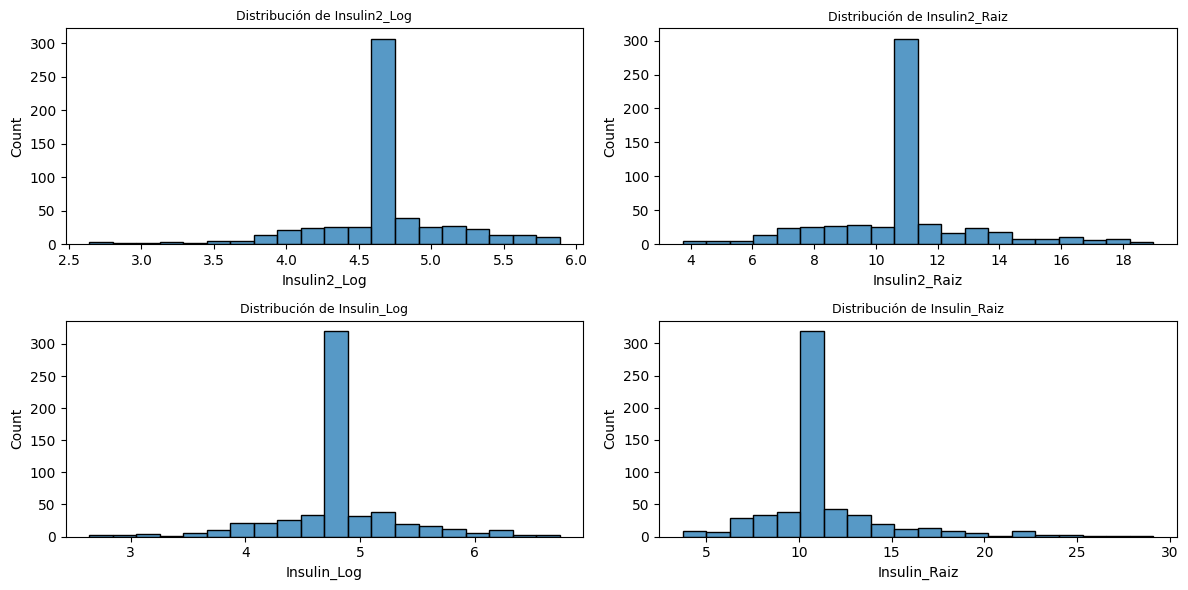

,Skew,ExcesoKurtosis
Insulin2_Log,-0.852993,3.346442
Insulin_Log,-0.252422,3.270943
Insulin2_Raiz,0.537646,2.028607
Insulin_Raiz,1.658970,5.710864


In [29]:
#realizamos los histogramas de las nuevas variables en X_train, como referencia,
#a ver si visualmente alguna tiene mas skewnes que otra
plt.figure(figsize=(12,6))
for i,col in enumerate (new_vars, 1):
    plt.subplot(2,2,i)
    sns.histplot (X_train[col],bins=20 )
    plt.title(f'Distribución de {col}', fontsize=9)
plt.tight_layout()
plt.show()

#calculamos Skewness y Kurtosis para ver cual de las nuevas variables tiene una distribución
#más parecida a una normal y empezar a trabajar con ella.
skew_kurt=pd.DataFrame({'Skew':X_train[new_vars].skew(), 'ExcesoKurtosis':X_train[new_vars].kurt()})
skew_kurt.sort_values('Skew', ascending=True)



De las variables que hemos creado, si hemos de empezar a entrenar algun modelo, probaremos primero con aquellas que su distribución  se parezca más a una normal. Por tanto, el orden sería:
* **Insulin_Log**: Datos de la variable Insulin, sin 0's (sustituidos por la mediana), Outliers con una transformación logarítmica
* **Insulin2_Raiz**: Datos de la variable Insulin, con los outliers transformados cambiando la unidad, sin 0's, transformados con mediana y aplicando una raiz cuadrada para realizar la transformación y evitar los outliers.

##**<font color='green'>4.6. Feature Scaling**

Dado que entre nuestros datos podemos encontrar valores muy diferentes, como por ejemplo la funcion estadística de Pedigree, que no suele pasar de 2 ó 3, y el valor de la glucosa de 200, para evitar que nuestro algoritmo tome ciertos valores por el hecho de que una variable tome valores mayores, escalaremos nuestras variables numericas.

Como teniamos algunos outliers, aunque los hemos tratado, mejor aplicaremos un el escalado con un RobustScaler, por si nos hubiera quedado alguno poco ajustado.

In [30]:
#seleccinamos las variables a escalar
cols_to_scale = [col for col in X_train.columns if not col.startswith('flag')]

#escalamos características seleccionadas
RScaler = RobustScaler()
X_train_RScaler = X_train.copy()
X_test_RScaler = X_test.copy()

X_train_RScaler[cols_to_scale] = RScaler.fit_transform(X_train_RScaler[cols_to_scale])
X_test_RScaler[cols_to_scale] = RScaler.transform(X_test_RScaler[cols_to_scale])

#vemos el resultado
X_train_RScaler.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,flag_mis_Glucose,flag_mis_BloodPressure,...,flag_outl_Insulin_cap,Insulin_cap,flag_outl_DiabetesPedigreeFunction_cap,DiabetesPedigreeFunction_cap,flag_outl_Insulin2_cap,Insulin2_cap,Insulin_Raiz,Insulin_Log,Insulin2_Raiz,Insulin2_Log
538,0.6,-0.418605,-0.750,-1.25,-7.2,-0.591398,0.306625,0.176471,0,0,...,0,-7.2,0,0.306625,0,-4.444444,-8.666390,-10.585572,-5.228018,-6.219212
186,0.8,0.976744,-0.375,0.00,0.0,-0.215054,0.018927,0.411765,0,0,...,0,0.0,0,0.018927,0,0.000000,0.000000,0.000000,0.000000,0.000000
488,1.8,-0.767442,0.000,0.25,0.0,-0.290323,-0.198107,1.000000,0,0,...,0,0.0,0,-0.198107,0,0.000000,0.000000,0.000000,0.000000,0.000000
397,-0.4,0.604651,0.750,-0.75,18.4,1.075269,1.767823,-0.411765,0,0,...,0,18.4,0,1.767823,0,14.518519,14.267383,11.247625,10.884066,8.326308
681,0.0,-0.348837,0.125,0.00,0.0,-0.311828,-0.642271,0.176471,0,0,...,0,0.0,0,-0.642271,0,0.000000,0.000000,0.000000,0.000000,0.000000


In [31]:
#registramos estas modificaciones y vemos el dataframe
log_registro ('X_train_RScaler', 'Todas', 'Escalado', 'RobustScaler', 'Aplicado en var numericas', 'Todas', 'Si')
log_registro ('X_test_RScaler', 'Todas', 'Escalado', 'RobustScaler', 'Aplicado en var numericas', 'Todas', 'Si')
log_diabetes.tail()

,DataSet,Variable,Problema,Accion,Detalle,LineasAfectadas,Pipeline?
59,X_test,Insulin_Log,Outliers,Creacion nueva variable,Log de Insulin,Todas,Si
60,X_train,Insulin_Raiz,Outliers,Creacion nueva variable,Raiz de Insulin,Todas,Si
61,X_test,Insulin_Raiz,Outliers,Creacion nueva variable,Raiz de Insulin,Todas,Si
62,X_train_RScaler,Todas,Escalado,RobustScaler,Aplicado en var numericas,Todas,Si
63,X_test_RScaler,Todas,Escalado,RobustScaler,Aplicado en var numericas,Todas,Si


##**<font color='green'>4.7. Datos desbalanceados**

En nuestro caso, vimos que aproximadamente tenemos un 35% de mujeres con diabetes y un 65% de mujeres sin diabetes, clases desbalanceadas.

Aplicaremos el método SMOTE por ser el más equilibrado.

In [32]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_RScaler, y_train)

print('Número de registros de X_train_RScaler: ', len(X_train_RScaler), '\nNúmero de lineas de X_train_bal: ', len(X_train_bal))
print('\n\nNúmero de lineas de y_train: ', len(y_train), '\nNúmero de lineas de y_train_bal: ', len(y_train_bal))
print('\nValores de y_train:\n', y_train.value_counts())
print('\nValores de y_train_bal:\n', y_train_bal.value_counts())

log_registro ('X_train_bal', 'Todas', 'Desbalanceo clases', 'SMOTE',
              'Aplicado en todo el dataframe', f'de {len(X_train_RScaler)} a {len(X_train_bal)}', 'No')
log_registro ('y_train_bal', 'y', 'Desbalanceo clases', 'SMOTE',
              'Aplicado en toda el dataframe', f'de {len(y_train)} a {len(y_train_bal)}', 'No')

print('\n\n')
log_diabetes.tail()

Número de registros de X_train_RScaler:  588 
Número de lineas de X_train_bal:  772


Número de lineas de y_train:  588 
Número de lineas de y_train_bal:  772

Valores de y_train:
 Outcome
0    386
1    202
Name: count, dtype: int64

Valores de y_train_bal:
 Outcome
0    386
1    386
Name: count, dtype: int64





,DataSet,Variable,Problema,Accion,Detalle,LineasAfectadas,Pipeline?
61,X_test,Insulin_Raiz,Outliers,Creacion nueva variable,Raiz de Insulin,Todas,Si
62,X_train_RScaler,Todas,Escalado,RobustScaler,Aplicado en var numericas,Todas,Si
63,X_test_RScaler,Todas,Escalado,RobustScaler,Aplicado en var numericas,Todas,Si
64,X_train_bal,Todas,Desbalanceo clases,SMOTE,Aplicado en todo el dataframe,de 588 a 772,No
65,y_train_bal,y,Desbalanceo clases,SMOTE,Aplicado en toda el dataframe,de 588 a 772,No


##**<font color='green'>4.6. Feature Selection**

Por ahora, no vamos a realizar ninguna acción en este apartado, al menos hasta que veamos si es necesario o no para mejorar el modelo

In [ ]:
# from sklearn.feature_selection import SelectKBest
# from sklearn.feature_selection import chi2

# test = SelectKBest (score_func =chi2, k=4)
# #con los datos que tenemos aplica el selector (fit contendra media y desviación)
# fit = test.fit(X_train, y_train)

# #devuelve las columnas con las que finalmente se queda después de la prueba
# X_selected = fit.transform(X_train)

# X_selected.head()


##**<font color='green'>4.7. Crear variables: INDICE HOMA**

Por el momento, no crearemos ninguna nueva variable. Si más adelante hay que hacer algna mejora en el modelo, podemos crear esta variable. Dejo algunos links para informarme, si fuera mecesario

https://www.tuasaude.com/es/indice-de-homa/

https://www.diabetrics.com/homa-utilidad-practica-medica

https://vivolabs.es/indice-de-homa/?srsltid=AfmBOoqfoX1LcxFo2qbt2ELEYYFE4ajuf4AAaHi1m3nCQ18tlBtIZIzL

https://www.redsalud.cl/salud-y-cuidados/que-mide-el-test-de-homa-ir



##**<font color='green'>4.8. Creación de los datasets con las diferentes transformaciones**

Finalmente, ahora que ya estan los datos pre-procesados para el siguiente paso, veamos con las diferentes variables que hemos ido creando con las transformaciones que hacíamos, las opciones que tenemos.

En el caso de la variable objetivo, será ma misma en cualquiera de las transformaciones que hemos hecho, por lo que la definiremos aqui mismo.

A continuación, vemos las diferentes transformaciones.






In [33]:
print(X_train_bal.columns)
print('\nNº total de variables: ', len(X_train_bal.columns))

#y_train_bal es valido para todas las transformaciones que hemos hecho en train, con SMOTE
#y_train_fin valdrá como y_train generico para todas las bases de trabajo con datos ajustados con SMOTE
y_train_fin = y_train_bal

#y_test no se ha modificado en ningun momento y sigue siendo valida para todas las X_test
#con las que trabajemos.

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'flag_mis_Glucose',
       'flag_mis_BloodPressure', 'flag_mis_SkinThickness', 'Insulin2',
       'flag_outl_Insulin2', 'flag_mis_Insulin', 'flag_mis_Insulin2',
       'flag_mis_BMI', 'flag_outl_BloodPressure_cap', 'BloodPressure_cap',
       'flag_outl_SkinThickness_cap', 'SkinThickness_cap',
       'flag_outl_Insulin_cap', 'Insulin_cap',
       'flag_outl_DiabetesPedigreeFunction_cap',
       'DiabetesPedigreeFunction_cap', 'flag_outl_Insulin2_cap',
       'Insulin2_cap', 'Insulin_Raiz', 'Insulin_Log', 'Insulin2_Raiz',
       'Insulin2_Log'],
      dtype='object')

Nº total de variables:  30


* **X_TRAIN_1**: X_train_bal [['Pregnancies', 'Glucose', 'BloodPressure_cap', 'SkinThickness_cap', 'Insulin_cap', 'BMI', 'DiabetesPedigreeFunction_cap', 'Age']]
>* Eliminadas las lineas con 3 o 4 missings en la misma linea.
>* Los **missings** de **Glucose**, **BloodPressure**, **SkinThickness**,  **BMI** e **Insulin**, imputados con mediana.
>* Outliers: Se aplica **winsorización** a **BloodPressure**, **SkinThickness**, **Insulin** y **DiabetesPedigreeFunction**
>* Se aplica **RobustScaler**
>* Se aplica **SMOTE** para datos desbalanceados


In [34]:
#X_train_1 = X_train_bal [['Pregnancies', 'Glucose', 'BloodPressure_cap',
#'SkinThickness_cap', 'Insulin_cap', 'BMI', 'DiabetesPedigreeFunction_cap', 'Age']]
#con sus flags correspondientes
X_train_1 = X_train_bal.drop(columns=['BloodPressure', 'SkinThickness', 'Insulin',
                                        'DiabetesPedigreeFunction', 'Insulin2',
                                        'flag_outl_Insulin2','flag_mis_Insulin2',
                                        'flag_outl_Insulin2_cap', 'Insulin2_cap',
                                        'Insulin_Raiz', 'Insulin_Log', 'Insulin2_Raiz',
                                        'Insulin2_Log'])
X_train_1_no_flags = X_train_1.drop(columns=[c for c in X_train_1.columns if c.startswith('flag')])

#en test no aplicamos el SMOTE, por lo que trabajamos con X_test_RScaler
X_test_1 = X_test_RScaler.drop(columns=['BloodPressure', 'SkinThickness', 'Insulin',
                                        'DiabetesPedigreeFunction', 'Insulin2',
                                        'flag_outl_Insulin2','flag_mis_Insulin2',
                                        'flag_outl_Insulin2_cap', 'Insulin2_cap',
                                        'Insulin_Raiz', 'Insulin_Log', 'Insulin2_Raiz',
                                        'Insulin2_Log'])
X_test_1_no_flags = X_test_1.drop(columns=[c for c in X_test_1.columns if c.startswith('flag')])

print('Forma de X_train_1: ', X_train_1.shape[0], ' observaciones x ', X_train_1.shape[1], ' variables')
print('Forma de X_train_1, sin flags: ', X_train_1_no_flags.shape[0], ' observaciones x ', X_train_1_no_flags.shape[1], ' variables')
print('Forma de y_train_fin: ', y_train_fin.shape[0], ' observaciones')
print('\nForma de X_test_1: ', X_test_1.shape[0], ' observaciones x ', X_test_1.shape[1], ' variables')
print('Forma de X_test_1, sin flags: ', X_test_1_no_flags.shape[0], ' observaciones x ', X_test_1_no_flags.shape[1], ' variables')
print('Forma de y_test: ', y_test.shape[0], ' observaciones')

Forma de X_train_1:  772  observaciones x  17  variables
Forma de X_train_1, sin flags:  772  observaciones x  8  variables
Forma de y_train_fin:  772  observaciones

Forma de X_test_1:  147  observaciones x  17  variables
Forma de X_test_1, sin flags:  147  observaciones x  8  variables
Forma de y_test:  147  observaciones


* **X_TRAIN_2**: X_train_bal [['Pregnancies', 'Glucose','BloodPressure_cap', 'SkinThickness_cap', 'BMI', 'DiabetesPedigreeFunction_cap', 'Age', 'Insulin_Log']]
>* Eliminadas las lineas con 3 o 4 missings en la misma linea
>* Los **missing** de **Glucose**, **BloodPressure**, **SkinThickness**,  **BMI** y **Insulin**, imputados con mediana.
>* Outliers: Se aplica **winsorización** a **BloodPressure**, **SkinThickness** y **DiabetesPedigreeFunction** y se aplica transformacion **logaritmica** a **Insulin**
>* Se aplica **RobustScaler**.
>* Se aplica **SMOTE** para datos desbalanceados.


In [35]:
#X_train_2 = X_train_bal [['Pregnancies', 'Glucose','BloodPressure_cap', 'SkinThickness_cap',
#'BMI', 'DiabetesPedigreeFunction_cap', 'Age', 'Insulin_Log']]
#con sus flags correspondientes
X_train_2 = X_train_bal.drop(columns=['BloodPressure', 'SkinThickness', 'Insulin',
                                      'DiabetesPedigreeFunction', 'Insulin2',
                                      'flag_outl_Insulin2','flag_mis_Insulin2',
                                      'flag_outl_Insulin_cap', 'Insulin_cap',
                                      'flag_outl_Insulin2_cap', 'Insulin2_cap',
                                      'Insulin_Raiz', 'Insulin2_Raiz',
                                      'Insulin2_Log'])
X_train_2_no_flags = X_train_2.drop(columns=[c for c in X_train_2.columns if c.startswith('flag')])

#en test no aplicamos el SMOTE, por lo que trabajamos con X_test_RScaler
X_test_2 = X_test_RScaler.drop(columns=['BloodPressure', 'SkinThickness', 'Insulin',
                                      'DiabetesPedigreeFunction', 'Insulin2',
                                      'flag_outl_Insulin2','flag_mis_Insulin2',
                                      'flag_outl_Insulin_cap', 'Insulin_cap',
                                      'flag_outl_Insulin2_cap', 'Insulin2_cap',
                                      'Insulin_Raiz', 'Insulin2_Raiz',
                                      'Insulin2_Log'])
X_test_2_no_flags = X_test_2.drop(columns=[c for c in X_test_2.columns if c.startswith('flag')])

print('Forma de X_train_2: ', X_train_2.shape[0], ' observaciones x ', X_train_2.shape[1], ' variables')
print('Forma de X_train_2, sin flags: ', X_train_2_no_flags.shape[0], ' observaciones x ', X_train_2_no_flags.shape[1], ' variables')
print('Forma de y_train_fin: ', y_train_fin.shape[0], ' observaciones')
print('\nForma de X_test_2: ', X_test_2.shape[0], ' observaciones x ', X_test_2.shape[1], ' variables')
print('Forma de X_test_2, sin flags: ', X_test_2_no_flags.shape[0], ' observaciones x ', X_test_2_no_flags.shape[1], ' variables')
print('Forma de y_test: ', y_test.shape[0], ' observaciones')

Forma de X_train_2:  772  observaciones x  16  variables
Forma de X_train_2, sin flags:  772  observaciones x  8  variables
Forma de y_train_fin:  772  observaciones

Forma de X_test_2:  147  observaciones x  16  variables
Forma de X_test_2, sin flags:  147  observaciones x  8  variables
Forma de y_test:  147  observaciones


* **X_TRAIN_3**:X_train_bal[['Pregnancies', 'Glucose', 'BloodPressure_cap', 'SkinThickness_cap', 'BMI',  'DiabetesPedigreeFunction_cap', 'Age', 'Insulin_Raiz']]
>* Eliminadas las lineas con 3 o 4 missings en la misma linea
>* Los **missing** de **Glucose**, **BloodPressure**, **SkinThickness**,  **BMI** y **Insulin**, imputados con mediana.
>* Outliers: Se aplica winsorización a **BloodPressure**, **SkinThickness** y **DiabetesPedigreeFunction** y se aplica transformacion con **raiz cuadrada** en **Insulin**.
>* Se aplica **RobustScaler**.
>* Se aplica **SMOTE** para datos desbalanceados.


In [36]:
#X_train_3 = X_train_bal [['Pregnancies', 'Glucose', 'BloodPressure_cap', 'SkinThickness_cap',
#'BMI', 'DiabetesPedigreeFunction_cap', 'Age', 'Insulin_Raiz']]
#con sus flags correspondientes
X_train_3 = X_train_bal.drop(columns=['BloodPressure', 'SkinThickness', 'Insulin',
                                      'DiabetesPedigreeFunction', 'Insulin2',
                                      'flag_outl_Insulin2','flag_mis_Insulin2',
                                      'flag_outl_Insulin_cap', 'Insulin_cap',
                                      'flag_outl_Insulin2_cap', 'Insulin2_cap',
                                      'Insulin_Log', 'Insulin2_Raiz',
                                      'Insulin2_Log'])
X_train_3_no_flags = X_train_3.drop(columns=[c for c in X_train_3.columns if c.startswith('flag')])

#en test no aplicamos el SMOTE, por lo que trabajamos con X_test_RScaler
X_test_3 = X_test_RScaler.drop(columns=['BloodPressure', 'SkinThickness', 'Insulin',
                                      'DiabetesPedigreeFunction', 'Insulin2',
                                      'flag_outl_Insulin2','flag_mis_Insulin2',
                                      'flag_outl_Insulin_cap', 'Insulin_cap',
                                      'flag_outl_Insulin2_cap', 'Insulin2_cap',
                                      'Insulin_Log', 'Insulin2_Raiz',
                                      'Insulin2_Log'])
X_test_3_no_flags = X_test_3.drop(columns=[c for c in X_test_3.columns if c.startswith('flag')])

print('Forma de X_train_3: ', X_train_3.shape[0], ' observaciones x ', X_train_3.shape[1], ' variables')
print('Forma de X_train_3, sin flags: ', X_train_3_no_flags.shape[0], ' observaciones x ', X_train_3_no_flags.shape[1], ' variables')
print('Forma de y_train_fin: ', y_train_fin.shape[0], ' observaciones')
print('\nForma de X_test_3: ', X_test_3.shape[0], ' observaciones x ', X_test_3.shape[1], ' variables')
print('Forma de X_test_3, sin flags: ', X_test_3_no_flags.shape[0], ' observaciones x ', X_test_3_no_flags.shape[1], ' variables')
print('Forma de y_test: ', y_test.shape[0], ' observaciones')

Forma de X_train_3:  772  observaciones x  16  variables
Forma de X_train_3, sin flags:  772  observaciones x  8  variables
Forma de y_train_fin:  772  observaciones

Forma de X_test_3:  147  observaciones x  16  variables
Forma de X_test_3, sin flags:  147  observaciones x  8  variables
Forma de y_test:  147  observaciones


* **X_TRAIN_4**: X_train_bal [['Pregnancies', 'Glucose', 'BloodPressure_cap', 'SkinThickness_cap', 'BMI',  'DiabetesPedigreeFunction_cap', 'Age', 'Insulin2_cap']]
>* Eliminadas las lineas con 3 o 4 missings en la misma linea
>* Se crea **Insulin2**, suponiendo que los valores más altos de Insulin, en realidad son errores de medición y se cambia la unidad de medida, con las correspondientes equivalencias.
>* Los **missing** de **Glucose**, **BloodPressure**, **SkinThickness**,  **BMI** e **Insulin2**, imputados con mediana.
>* Outliers: Se aplica winsorización a **BloodPressure**, **SkinThickness**, **DiabetesPedigreeFunction** e **Insulin2**.
>* Se aplica **RobustScaler**.
>* Se aplica **SMOTE** para datos desbalanceados.

In [37]:
#X_train_4 = X_train_bal [['Pregnancies', 'Glucose', 'BloodPressure_cap', 'SkinThickness_cap',
#'BMI', 'DiabetesPedigreeFunction_cap', 'Age', 'Insulin2_cap']]
#con sus flags correspondientes

X_train_4 = X_train_bal.drop(columns=['BloodPressure', 'SkinThickness', 'Insulin',
                                      'DiabetesPedigreeFunction', 'Insulin2',
                                      'flag_mis_Insulin',
                                      'flag_outl_Insulin_cap', 'Insulin_cap',
                                      'Insulin_Raiz', 'Insulin_Log',
                                      'Insulin2_Raiz', 'Insulin2_Log'])
X_train_4_no_flags = X_train_4.drop(columns=[c for c in X_train_4.columns if c.startswith('flag')])

#en test no aplicamos el SMOTE, por lo que trabajamos con X_test_RScaler
X_test_4 = X_test_RScaler.drop(columns=['BloodPressure', 'SkinThickness', 'Insulin',
                                      'DiabetesPedigreeFunction', 'Insulin2',
                                      'flag_mis_Insulin',
                                      'flag_outl_Insulin_cap', 'Insulin_cap',
                                      'Insulin_Raiz', 'Insulin_Log',
                                      'Insulin2_Raiz', 'Insulin2_Log'])
X_test_4_no_flags = X_test_4.drop(columns=[c for c in X_test_4.columns if c.startswith('flag')])

print('Forma de X_train_4: ', X_train_4.shape[0], ' observaciones x ', X_train_4.shape[1], ' variables')
print('Forma de X_train_4, sin flags: ', X_train_4_no_flags.shape[0], ' observaciones x ', X_train_4_no_flags.shape[1], ' variables')
print('Forma de y_train_fin: ', y_train_fin.shape[0], ' observaciones')
print('\nForma de X_test_4: ', X_test_4.shape[0], ' observaciones x ', X_test_4.shape[1], ' variables')
print('Forma de X_test_4, sin flags: ', X_test_4_no_flags.shape[0], ' observaciones x ', X_test_4_no_flags.shape[1], ' variables')
print('Forma de y_test: ', y_test.shape[0], ' observaciones')

Forma de X_train_4:  772  observaciones x  18  variables
Forma de X_train_4, sin flags:  772  observaciones x  8  variables
Forma de y_train_fin:  772  observaciones

Forma de X_test_4:  147  observaciones x  18  variables
Forma de X_test_4, sin flags:  147  observaciones x  8  variables
Forma de y_test:  147  observaciones


* **X_TRAIN_5**: X_train_bal [['Pregnancies', 'Glucose', 'BloodPressure_cap', 'SkinThickness_cap',  'BMI', 'DiabetesPedigreeFunction_cap', 'Age', 'Insulin2_Log']]
>* Eliminadas las lineas con 3 o 4 missings en la misma linea.
>* Se crea **Insulin2**, suponiendo que los valores más altos de Insulin, en realidad son errores de medición y cambiamos la unidad de medida, con las correspondientes equivalencias.
>* Los **missing** de **Glucose**, **BloodPressure**, **SkinThickness**,  **BMI** e **Insulin2**, imputados con mediana.
>* Outliers: Se aplica **winsorización** a **BloodPressure**, **SkinThickness** Y **DiabetesPedigreeFunction** y se aplica transformación **logarítmica** en **Insulin2**.
>* Se aplica **RobustScaler**.
>* Se aplica **SMOTE** para datos desbalanceados.



In [38]:
#X_train_5 = X_train_bal [['Pregnancies', 'Glucose', 'BloodPressure_cap', 'SkinThickness_cap',
#'BMI', 'DiabetesPedigreeFunction_cap', 'Age', 'Insulin2_Log']]
#con sus flags correspondientes

X_train_5 = X_train_bal.drop(columns=['BloodPressure', 'SkinThickness', 'Insulin',
                                      'DiabetesPedigreeFunction', 'Insulin2',
                                      'flag_mis_Insulin', 'flag_outl_Insulin_cap',
                                      'Insulin_cap', 'flag_outl_Insulin2_cap',
                                      'Insulin2_cap', 'Insulin_Raiz', 'Insulin_Log',
                                      'Insulin2_Raiz'])
X_train_5_no_flags = X_train_5.drop(columns=[c for c in X_train_5.columns if c.startswith('flag')])

#en test no aplicamos el SMOTE, por lo que trabajamos con X_test_RScaler
X_test_5 = X_test_RScaler.drop(columns=['BloodPressure', 'SkinThickness', 'Insulin',
                                      'DiabetesPedigreeFunction', 'Insulin2',
                                      'flag_mis_Insulin', 'flag_outl_Insulin_cap',
                                      'Insulin_cap', 'flag_outl_Insulin2_cap',
                                      'Insulin2_cap', 'Insulin_Raiz', 'Insulin_Log',
                                      'Insulin2_Raiz'])
X_test_5_no_flags = X_test_5.drop(columns=[c for c in X_test_5.columns if c.startswith('flag')])

print('Forma de X_train_5: ', X_train_5.shape[0], ' observaciones x ', X_train_5.shape[1], ' variables')
print('Forma de X_train_5, sin flags: ', X_train_5_no_flags.shape[0], ' observaciones x ', X_train_5_no_flags.shape[1], ' variables')
print('Forma de y_train_fin: ', y_train_fin.shape[0], ' observaciones')
print('\nForma de X_test_5: ', X_test_5.shape[0], ' observaciones x ', X_test_5.shape[1], ' variables')
print('Forma de X_test_5, sin flags: ', X_test_5_no_flags.shape[0], ' observaciones x ', X_test_5_no_flags.shape[1], ' variables')
print('Forma de y_test: ', y_test.shape[0], ' observaciones')

Forma de X_train_5:  772  observaciones x  17  variables
Forma de X_train_5, sin flags:  772  observaciones x  8  variables
Forma de y_train_fin:  772  observaciones

Forma de X_test_5:  147  observaciones x  17  variables
Forma de X_test_5, sin flags:  147  observaciones x  8  variables
Forma de y_test:  147  observaciones


* **X_TRAIN_6**: X_train_bal[['Pregnancies', 'Glucose', 'BloodPressure_cap', 'SkinThickness_cap', 'BMI',  'DiabetesPedigreeFunction_cap', 'Age', 'Insulin2_Raiz']]
>* Eliminadas las lineas con 3 o 4 missings en la misma linea.
>* Se crea **Insulin2**, suponiendo que los valores más altos de Insulin, en realidad son errores de medición y cambiamos la unidad de medida, con las correspondientes equivalencias.
>* Los **missing** de **Glucose**, **BloodPressure**, **SkinThickness**,  **BMI** e **Insulin2**, imputados con mediana.
>* Outliers: Se aplica **winsorización** a **BloodPressure**, **SkinThickness** Y **DiabetesPedigreeFunction** y se aplica transformación con **Raiz Cuadrada** en **Insulin2**.
>* Se aplica **RobustScaler**.
>* Se aplica **SMOTE** para datos desbalanceados.

In [39]:
#X_train_6 = X_train_bal [['Pregnancies', 'Glucose', 'BloodPressure_cap', 'SkinThickness_cap',
#'BMI', 'DiabetesPedigreeFunction_cap', 'Age', 'Insulin2_Raiz']]
#con sus flags correspondientes

X_train_6 = X_train_bal.drop(columns=['BloodPressure', 'SkinThickness', 'Insulin',
                                      'DiabetesPedigreeFunction', 'Insulin2',
                                      'flag_mis_Insulin', 'flag_outl_Insulin_cap',
                                      'Insulin_cap', 'flag_outl_Insulin2_cap',
                                      'Insulin2_cap', 'Insulin_Raiz', 'Insulin_Log',
                                      'Insulin2_Log'])
X_train_6_no_flags = X_train_6.drop(columns=[c for c in X_train_6.columns if c.startswith('flag')])

#en test no aplicamos el SMOTE, por lo que trabajamos con X_test_RScaler
X_test_6 = X_test_RScaler.drop(columns=['BloodPressure', 'SkinThickness', 'Insulin',
                                      'DiabetesPedigreeFunction', 'Insulin2',
                                      'flag_mis_Insulin', 'flag_outl_Insulin_cap',
                                      'Insulin_cap', 'flag_outl_Insulin2_cap',
                                      'Insulin2_cap', 'Insulin_Raiz', 'Insulin_Log',
                                      'Insulin2_Log'])
X_test_6_no_flags = X_test_6.drop(columns=[c for c in X_test_6.columns if c.startswith('flag')])

print('Forma de X_train_6: ', X_train_6.shape[0], ' observaciones x ', X_train_6.shape[1], ' variables')
print('Forma de X_train_6, sin flags: ', X_train_6_no_flags.shape[0], ' observaciones x ', X_train_6_no_flags.shape[1], ' variables')
print('Forma de y_train_fin: ', y_train_fin.shape[0], ' observaciones')
print('\n\nForma de X_test_6: ', X_test_6.shape[0], ' observaciones x ', X_test_6.shape[1], ' variables')
print('Forma de X_test_6, sin flags: ', X_test_6_no_flags.shape[0], ' observaciones x ', X_test_6_no_flags.shape[1], ' variables')
print('Forma de y_test: ', y_test.shape[0], ' observaciones')

Forma de X_train_6:  772  observaciones x  17  variables
Forma de X_train_6, sin flags:  772  observaciones x  8  variables
Forma de y_train_fin:  772  observaciones


Forma de X_test_6:  147  observaciones x  17  variables
Forma de X_test_6, sin flags:  147  observaciones x  8  variables
Forma de y_test:  147  observaciones


##**<font color='green'>4.9. Resumen de datasets para entrenar modelos**

Con las transformaciones aplicadas durante esta etapa, hemos conseguido 6 cojuntos diferentes de datos. Por ahora, empezaremos comparando el primeros de ellos y si necesitamos probar mas, seguiriamos con las otras 3 muestras propuestas:

Los 3 primeros juegos a tener en cuenta, son los siguientes:
1. **X_train_1, y_train_fin, X_test_1, y_test** (todos los missings imputados con mediana, todos los outliers winsorizados, escalado con RobustScaler y aplicado SMOTE).


1. **X_train_2, y_train_fin, X_test_2, y_test** (todos los missings imputados con mediana, outliers winsorizados + transformación logarítmica de Insulin, RobustScaler, SMOTE).


1. **X_train_6, y_train_fin, X_test_6, y_test** (todos los missings imputados con mediana, creacion de Insulin2 en base a la corrección de medidas de los outliers de Insulin, outliers winsorizados + transformación raiz cuadrada de Insulin2, RobustScaler, SMOTE).

# **<font color='green'>ETAPA 5: ENTRENAMIENTO DE MODELOS CON X_train_1**

Los dataframes que usaremos son **X_train_1, y_train_fin, X_test_1, y_test**

Recordemos que estos datos se han tratado de la forma siguiente:  **todos los missings imputados con mediana, todos los outliers winsorizados, escalado con RobustScaler y aplicado SMOTE**.



In [40]:
#importo librerías

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV
import matplotlib.pyplot as plt


##**<font color='green'>5.1. X_train_1: Entrenamiento, predicción y evaluación**
Empezamos evaluando los modelos siguientes: Regresión logística, Árbol de decisión, Random Forest y XGBoost

In [41]:
# definimos los modelos
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(eval_metric='auc')
}

#entrenamos los modelos y realizamos la predicción con los datos de test con X_train_1
for name, model in models.items():
    model.fit(X_train_1, y_train_fin)
    y_pred = model.predict(X_test_1)
    print(f'\n{name}')
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print('ROC AUC:', roc_auc_score(y_test, model.predict_proba(X_test_1)[:, 1]))



Logistic Regression
[[72 24]
 [16 35]]
              precision    recall  f1-score   support

           0       0.82      0.75      0.78        96
           1       0.59      0.69      0.64        51

    accuracy                           0.73       147
   macro avg       0.71      0.72      0.71       147
weighted avg       0.74      0.73      0.73       147

ROC AUC: 0.801266339869281

Decision Tree
[[73 23]
 [17 34]]
              precision    recall  f1-score   support

           0       0.81      0.76      0.78        96
           1       0.60      0.67      0.63        51

    accuracy                           0.73       147
   macro avg       0.70      0.71      0.71       147
weighted avg       0.74      0.73      0.73       147

ROC AUC: 0.7135416666666665

Random Forest
[[77 19]
 [18 33]]
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        96
           1       0.63      0.65      0.64        51

    accuracy       

De los 4 modelos entrenados, descartamos el Decision Tree, ya que es el que toma el valor más bajo de la curva ROC-AUC (0,7135), además que el resto de métricas se ven mejoradas por Random Forest.

 Por lo que nuestro TOP 3, de momento, se forma por (ordenados por el valor ROC-AUC):
* Random Forest (0.8027)
* Regresión logística (0.8013)
* XGBoost (0.7766)

Además, en este caso particularmente, es importante darle importancia a que los casos reales que SÍ que tienen diabetes, se predigan como que SÍ que tiene diabetes y eso lo mediremos con el recall del valor 1. Por tanto, tomará especial relevancia esta métrica. En el caso que acabamos de descartar del modelo de Decision Tree, es, además del que tiene el valor más bajo para ROC-AUC, el que tiene el valor más bajo para Recall de la clase 1.

Recordemos también que en los datos hemos llevado un registro con las variables "flag" que **marcaban que lineas se veian afectadas con cada una de las transformaciones realizadas en la etapa anterior**. Los modelos que se acaban de entrenar cuenta con todas esas variables, pero veamos que ocurre si se entrenan los mismos modelos pero sin tener en cuenta esas variables "flag". Habrán mejorado las métricas?



In [42]:
#entrenamos los modelos y realizamos la predicción con los datos de test con X_train_1_no_flags
for name, model in models.items():
    model.fit(X_train_1_no_flags, y_train_fin)
    y_pred = model.predict(X_test_1_no_flags)
    print(f'\n{name} (no flags)')
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print('ROC AUC:', roc_auc_score(y_test, model.predict_proba(X_test_1_no_flags)[:, 1]))


Logistic Regression (no flags)
[[69 27]
 [16 35]]
              precision    recall  f1-score   support

           0       0.81      0.72      0.76        96
           1       0.56      0.69      0.62        51

    accuracy                           0.71       147
   macro avg       0.69      0.70      0.69       147
weighted avg       0.73      0.71      0.71       147

ROC AUC: 0.7937091503267975

Decision Tree (no flags)
[[72 24]
 [19 32]]
              precision    recall  f1-score   support

           0       0.79      0.75      0.77        96
           1       0.57      0.63      0.60        51

    accuracy                           0.71       147
   macro avg       0.68      0.69      0.68       147
weighted avg       0.71      0.71      0.71       147

ROC AUC: 0.6887254901960784

Random Forest (no flags)
[[73 23]
 [13 38]]
              precision    recall  f1-score   support

           0       0.85      0.76      0.80        96
           1       0.62      0.75      0

In [43]:
model=RandomForestClassifier(random_state=42)
model.fit(X_train_1_no_flags, y_train_fin)
model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Podemos observar que en los entrenamientos con los datos sin las variables "flag":
* **Regresión**: El modelo es mejor considerando las "flag". 0.8013 (ROC-AUC), 0.69 (recall 1), 0.64 (f1 score 1) con las flags vs 0.7937 (ROC-AUC), 0.69 (recall 1), 0.62 (f1 score 1)
* **Decision Tree**: El modelo es mejor considerando las "flag". 0.7135 (ROC-AUC), 0.67 (recall 1), 0.63 (f1 score 1) con las flags vs 0.6887 (ROC-AUC), 0.63 (recall 1), 0.60 (f1 score 1)
* **Random Forest**: **En este caso valdría la pena tenerlo en cuenta**, ya que el modelo, aunque tiene un valor de ROC-AUC similar al obtenido con los datos incluyendo las variables "flag", los datos de recall y f1 score para el valor 1 (positivo) mejoran de forma interesante. Los valores que tenemos pasan de 0.8027 (ROC-AUC), 0.65 (recall 1), 0.64 (f1 score 1) con las flags vs 0.7749 (ROC-AUC), 0.71 (recall 1), 0.66 (f1 score 1).
* **XGBoost**: En este caso, las diferencias entre usar flags o no es casi imperceptible: donde crece una métrica, decrece la anterior, por lo que nos quedariamos con el primero, teniendo en cuenta las variables flags. 0.7766 (ROC-AUC), 0.73 (recall 1), 0.66 (f1 score 1) con las flags vs 0.7749 (ROC-AUC), 0.71 (recall 1), 0.66 (f1 score 1)

De momento, añadiremos el modelo de Random Forest entrenando sin las variables flag al top que teniamos.

Veamos un par más de modelos más, probando los datos con variables flag y sin:

In [44]:
#entrenamos KNN y SVM y realizamos la predicción con los datos de test con X_train_1 con flags y sin flags
#KNN
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_1, y_train_fin)
y_pred_knn = knn.predict(X_test_1)
print('KNN')
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
print('ROC AUC:', roc_auc_score(y_test, knn.predict_proba(X_test_1)[:, 1]))

#KNN sin flags
knn.fit(X_train_1_no_flags, y_train_fin)
y_pred_knn = knn.predict(X_test_1_no_flags)
print('\n\nKNN (sin flags')
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
print('ROC AUC:', roc_auc_score(y_test, knn.predict_proba(X_test_1_no_flags)[:, 1]))

#SVM
svm=SVC(probability=True, kernel='rbf', C=1,random_state=42)
svm.fit(X_train_1, y_train_fin)
y_pred_svc = svm.predict(X_test_1)
print('\n\nSVM')
print(confusion_matrix(y_test, y_pred_svc))
print(classification_report(y_test, y_pred_svc))
print('ROC AUC:', roc_auc_score(y_test, svm.predict_proba(X_test_1)[:, 1]))

#SVM sin flags
svm.fit(X_train_1_no_flags, y_train_fin)
y_pred_svc = svm.predict(X_test_1_no_flags)
print('\n\nSVM (sin flags)')
print(confusion_matrix(y_test, y_pred_svc))
print(classification_report(y_test, y_pred_svc))
print('ROC AUC:', roc_auc_score(y_test, svm.predict_proba(X_test_1_no_flags)[:, 1]))

KNN
[[68 28]
 [20 31]]
              precision    recall  f1-score   support

           0       0.77      0.71      0.74        96
           1       0.53      0.61      0.56        51

    accuracy                           0.67       147
   macro avg       0.65      0.66      0.65       147
weighted avg       0.69      0.67      0.68       147

ROC AUC: 0.6957720588235294


KNN (sin flags
[[71 25]
 [20 31]]
              precision    recall  f1-score   support

           0       0.78      0.74      0.76        96
           1       0.55      0.61      0.58        51

    accuracy                           0.69       147
   macro avg       0.67      0.67      0.67       147
weighted avg       0.70      0.69      0.70       147

ROC AUC: 0.7155841503267973


SVM
[[66 30]
 [13 38]]
              precision    recall  f1-score   support

           0       0.84      0.69      0.75        96
           1       0.56      0.75      0.64        51

    accuracy                           0.7

Viendo los resultados, el metodo KNN lo descartamos en ambos casos, ya que la curva ROC-AUC es menor que los modelos que ya teniamos en el TOP 4 y tambien el valor del resto de métricas.

En el caso del modelo de SVM, se observa que el valor de ROC-AUC es un poco mejor que el último modelo que teniamos en el Top 4 (XGBoost, 0.7766 vs SVM, 0.7837 o 0.7850), pero observando los valores de recall, vemos que en el XGBoost el recall para 0 es de 0.75 y el recall para 1 es de 0.73, mientras que para cualquiera de los dos modelos de SVM el recall para la clase 1 es similar (0.75 ó 0.76) pero para la clase 0 es bastante menor (0.69 ó 0.67), lo que implica que el modelo XGBoost nos daria mejor resultado en ambas clases, siendo el más equilibrado.

Por tanto, nuestro Top 4 finalista, ordenado por los valores de la curva ROC-AUC, es:
>1. Random Forest (entrenado con flags) (ROC-AUC: 0.8027) *(Recall 1: 0.65, recall 0:0.8)*
>1. Logistic Regression (entrenado con flags) (ROC-AUC: 0.8013) *(Recall 1: 0.69, recall 0:0.75)*
>1. Random Forest (entrenado sin flags) (ROC-AUC: 0.8002) *(Recall 1: 0.75, recall 0: 0.76)*
>1. XGBoost (entrenado con flags) (ROC-AUC: 0.7766) *(Recall 1: 0.73, recall 0: 0.75)*

Veamos con las otros dos dataframes que comentábamos, si obtenemos algún otro modelo con mejor puntuación que lo que hemos conseguido hasta ahora.

##**<font color='green'>5.2. X_train_2: Entrenamiento, predicción y evaluación**
Vamos a evaluar los mismos modelos que hicimos con X_train_1 (Regresión logística, Árbol de decisión, Random Forest, XGBoost, KNN y SVM), pero con X_train_2.

Recordemos que estos datos se han tratado de la forma siguiente:  **todos los missings imputados con mediana, outliers winsorizados + transformación logarítmica de Insulin, RobustScaler, SMOTE**.

Los dataframes que usaremos son **X_train_2, y_train_fin, X_test_2, y_test**



In [45]:
#incluimos los modelos de KNN y SVM también en el diccionario:
models.update ({
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(probability=True, kernel='rbf', C=1,random_state=42)
})
#entrenamos los modelos y realizamos la predicción con los datos de test con X_train_2
for name, model in models.items():
    model.fit(X_train_2, y_train_fin)
    y_pred = model.predict(X_test_2)
    print(f'\n{name}')
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print('ROC AUC:', roc_auc_score(y_test, model.predict_proba(X_test_2)[:, 1]))

#entrenamos los modelos y realizamos la predicción con los datos de test con X_train_2_no_flags
for name, model in models.items():
    model.fit(X_train_2_no_flags, y_train_fin)
    y_pred = model.predict(X_test_2_no_flags)
    print(f'\n{name} (sin flags)')
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print('ROC AUC:', roc_auc_score(y_test, model.predict_proba(X_test_2_no_flags)[:, 1]))


Logistic Regression
[[72 24]
 [16 35]]
              precision    recall  f1-score   support

           0       0.82      0.75      0.78        96
           1       0.59      0.69      0.64        51

    accuracy                           0.73       147
   macro avg       0.71      0.72      0.71       147
weighted avg       0.74      0.73      0.73       147

ROC AUC: 0.8016748366013072

Decision Tree
[[74 22]
 [18 33]]
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        96
           1       0.60      0.65      0.62        51

    accuracy                           0.73       147
   macro avg       0.70      0.71      0.70       147
weighted avg       0.73      0.73      0.73       147

ROC AUC: 0.7089460784313725

Random Forest
[[76 20]
 [16 35]]
              precision    recall  f1-score   support

           0       0.83      0.79      0.81        96
           1       0.64      0.69      0.66        51

    accuracy      

Teniendo en cuenta los 4 modelos que ya habíamos incluido en nuestro top 4, de estos nuevos modelos que hemos visto solo tendremos en cuenta aquellos que supongan una mejora considerable. Tomaremos los modelos con un ROC AUC superior a 0.79 y que tengan los valores de recall para 0 y 1 similares y por encima de 0.75 los dos, dado que serían los que podríamos considerar mejores que las opciones que ya tenemos.

Siguiendo esas pautas, **no encontramos ningun modelo que parezca superior a lo que ya tenemos en nuestra lista**. Si que hay varios modelos similares que cumplen con una de las dos condiones y que podríamos tener en cuenta si no encontramos ningun modelo con un rendimiento suficientemente bueno de entre los que tenemos en nuestro top 4. Encontrariamos modelos como Random Forest (sin flags) o XGBoost (sin flags)

##**<font color='green'>5.3. X_train_6: Entrenamiento, predicción y evaluación**
Recordemos que estos datos se han tratado de la forma siguiente:  **todos los missings imputados con mediana, creacion de Insulin2 en base a la corrección de medidas de los outliers de Insulin, outliers winsorizados + transformación raiz cuadrada de Insulin2, RobustScaler, SMOTE**.

Los dataframes que usaremos son **X_train_6, y_train_fin, X_test_6, y_test**

Empezamos evaluando los modelos: Regresión logística, Árbol de decisión, Random Forest, XGBoost, KNN y SVM.

In [46]:
#entrenamos los modelos y realizamos la predicción con los datos de test con X_train_6
for name, model in models.items():
    model.fit(X_train_6, y_train_fin)
    y_pred = model.predict(X_test_6)
    print(f'\n{name}')
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print('ROC AUC:', roc_auc_score(y_test, model.predict_proba(X_test_6)[:, 1]))

#entrenamos los modelos y realizamos la predicción con los datos de test con X_train_6_no_flags
for name, model in models.items():
    model.fit(X_train_6_no_flags, y_train_fin)
    y_pred = model.predict(X_test_6_no_flags)
    print(f'\n{name} (sin flags)')
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print('ROC AUC:', roc_auc_score(y_test, model.predict_proba(X_test_6_no_flags)[:, 1]))


Logistic Regression
[[70 26]
 [16 35]]
              precision    recall  f1-score   support

           0       0.81      0.73      0.77        96
           1       0.57      0.69      0.62        51

    accuracy                           0.71       147
   macro avg       0.69      0.71      0.70       147
weighted avg       0.73      0.71      0.72       147

ROC AUC: 0.7975898692810457

Decision Tree
[[76 20]
 [19 32]]
              precision    recall  f1-score   support

           0       0.80      0.79      0.80        96
           1       0.62      0.63      0.62        51

    accuracy                           0.73       147
   macro avg       0.71      0.71      0.71       147
weighted avg       0.74      0.73      0.74       147

ROC AUC: 0.7095588235294117

Random Forest
[[78 18]
 [16 35]]
              precision    recall  f1-score   support

           0       0.83      0.81      0.82        96
           1       0.66      0.69      0.67        51

    accuracy      

Igual que vimos con las transformaciones recogidas en el data frame X_train_2, con las transformaciones actuales recogidas en X_train_6 se observa que alguno de los modelos se aproximan a los que ya hemos incluido en nuestro top 4, pero no parecen que obtengan mejores puntuaciones que las que teníamos. Por tanto, seguiremos avanzando con el top 4 que habíamos definido y en caso de no obtener los resultados esperados, podemos retomar esos modelos con puntuaciones similares.

# **<font color='green'>ETAPA 6: OPTIMIZACIÓN DE PARÁMETROS**

Después de evaluar algunos modelos con diferentes transformaciones, el top 4 con el que vamos a trabajar para optimizar los parámetros es el siguiente (ordenado por valores de ROC-AUC):
>1. Random Forest (entrenado con flags) (ROC-AUC: 0.8027) *(Recall 1: 0.65, recall 0:0.8)*
>1. Logistic Regression (entrenado con flags) (ROC-AUC: 0.8013) *(Recall 1: 0.69, recall 0:0.75)*
>1. Random Forest (entrenado sin flags) (ROC-AUC: 0.8002) *(Recall 1: 0.75, recall 0: 0.76)*
>1. XGBoost (entrenado con flags) (ROC-AUC: 0.7766) *(Recall 1: 0.73, recall 0: 0.75)*

## **<font color='green'>6.1. Random Forest (X_train_1 CON FLAGS)**

In [47]:
ranfor=RandomForestClassifier(random_state=42)

param_grid_ranfor={
    "n_estimators": [100, 200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", 0.5],
}

random_ranfor=RandomizedSearchCV(ranfor, param_grid_ranfor, n_iter= 50, scoring='roc_auc', cv=5, n_jobs=-1, random_state=42)

random_ranfor.fit(X_train_1, y_train_fin)

print('Best params (Random Forest con flags):', random_ranfor.best_params_)
print('Best score(Roc-Auc):', random_ranfor.best_score_)

Best params (Random Forest con flags): {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Best score(Roc-Auc): 0.9067953691330315


## **<font color='green'>6.2. Logistic Regression**

In [48]:
logreg = LogisticRegression(max_iter=1000)

param_grid_logreg = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

#scoring aplica la métrica que queremos usar para comparar
#cv indica las muestras que queremos hacer para aplicar cross-validation
#n_jobs=-1 es para paralelizar en diferentes cpu
grid_logreg = GridSearchCV(logreg, param_grid_logreg, scoring= 'roc_auc', cv=5, n_jobs=-1)
grid_logreg.fit(X_train_1, y_train_fin)

print("Best params (Logistic):", grid_logreg.best_params_)
print("Best score (Roc-Auc):", grid_logreg.best_score_)

Best params (Logistic): {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best score (Roc-Auc): 0.8540303851992164


c:\Sara\Workspace_Proyectos\Proyecto_Diabetes-02.2026\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


##**<font color='green'>6.3. Random Forest (x_train_1_no_flags)**

In [49]:
ranfor=RandomForestClassifier(random_state=42)

param_grid_ranfor={
    "n_estimators": [100, 200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", 0.5],
}

random_ranfor=RandomizedSearchCV(ranfor, param_grid_ranfor, n_iter= 50, scoring='roc_auc', cv=5, n_jobs=-1, random_state=42)

random_ranfor.fit(X_train_1_no_flags, y_train_fin)

print('Best params (Random Forest con flags):', random_ranfor.best_params_)
print('Best score(Roc-Auc):', random_ranfor.best_score_)

Best params (Random Forest con flags): {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Best score(Roc-Auc): 0.9055773231097906


##**<font color='green'>6.4. XGBoost**

In [50]:
xgb = XGBClassifier(eval_metric='auc', random_state = 42)

param_grid_xgb = {
    'n_estimators': [200, 400],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

random_xgb = RandomizedSearchCV(xgb, param_grid_xgb, scoring='roc_auc', cv=5, n_jobs=-1)
random_xgb.fit(X_train_1, y_train_fin)

print("Best params (XGBoost):", random_xgb.best_params_)
print("Best score (roc-auc):", random_xgb.best_score_)

Best params (XGBoost): {'subsample': 1, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1}
Best score (roc-auc): 0.8915296824387735


Siendo rigurosos, el que tiene un valor mayor para la métrica ROC-AUC es el modelo de Random Forest, entrenado con las variables flags (ROC-AUC: 0.9068). Aunque tanto las métricas de Random Forest sin las variables flags (ROC-AUC: 0.9056) y el modelo obtenido de XGBoost (ROC-AUC: 0.8915) son muy similares.

Dado que son tan parecidas entre sus métricas, eveluaremos los 3 modelos para asegurarnos que tomamos el mejor de ellos.

In [51]:
#definimos los 3 modelos con los mejores hiperparámetros
#Random Forest entrenado CON flags
ranfor_flags_opt = RandomForestClassifier(n_estimators=400, min_samples_split=2,
                                          min_samples_leaf=1, max_features='sqrt', max_depth=20, random_state=42)
ranfor_flags_opt.fit(X_train_1, y_train_fin)
y_pred_ranfor_flags=ranfor_flags_opt.predict(X_test_1)

#Random Forest entrenado SIN flags
ranfor_no_flags_opt = RandomForestClassifier(n_estimators=200, min_samples_split=2,
                                             min_samples_leaf=1, max_features='sqrt', max_depth=20, random_state=42)
ranfor_no_flags_opt.fit(X_train_1_no_flags, y_train_fin)
y_pred_ranfor_no_flags=ranfor_no_flags_opt.predict(X_test_1_no_flags)

#XGBoost entrenado CON flags
xgb_opt = XGBClassifier(subsample=1, n_estimators=200, max_depth=7, learning_rate=0.1,
                        colsample_bytree=1, eval_metric='auc', random_state = 42)
xgb_opt.fit(X_train_1, y_train_fin)
y_pred_xgb=xgb_opt.predict(X_test_1)



##**<font color='green'>6.5. Métricas evaluación**

###**<font color='green'>6.5.1. Random Forest (con flags)**


MÉTRICAS DE EVALUACIÓN PARA RANDOM FOREST (CON FLAGS)




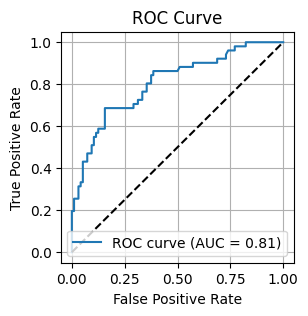

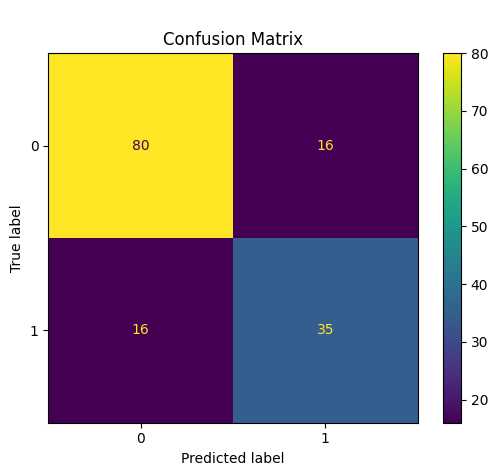



               precision    recall  f1-score   support

           0       0.83      0.83      0.83        96
           1       0.69      0.69      0.69        51

    accuracy                           0.78       147
   macro avg       0.76      0.76      0.76       147
weighted avg       0.78      0.78      0.78       147



In [52]:
#dibujo la curva ROC-AUC para Random Forest (con flags)
y_proba = ranfor_flags_opt.predict_proba(X_test_1)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

print(f'\n{under}{bold}MÉTRICAS DE EVALUACIÓN PARA RANDOM FOREST (CON FLAGS){reset}\n\n')
plt.figure(figsize=(3,3))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

#dibujo la matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ranfor_flags)
print('\n')
plt.title("\nConfusion Matrix")
plt.grid(False)
plt.show()

#muestro las métricas
print('\n\n', classification_report(y_test, y_pred_ranfor_flags))

###**<font color='green'>6.5.2. Random Forest (sin flags)**


MÉTRICAS DE EVALUACIÓN PARA RANDOM FOREST (SIN FLAGS)




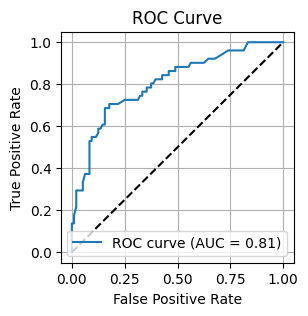

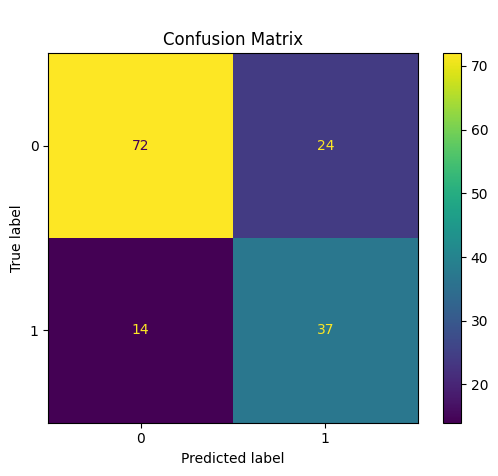



               precision    recall  f1-score   support

           0       0.84      0.75      0.79        96
           1       0.61      0.73      0.66        51

    accuracy                           0.74       147
   macro avg       0.72      0.74      0.73       147
weighted avg       0.76      0.74      0.75       147



In [53]:
#dibujo la curva ROC-AUC para Random Forest (sin flags)
y_proba = ranfor_no_flags_opt.predict_proba(X_test_1_no_flags)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

print(f'\n{under}{bold}MÉTRICAS DE EVALUACIÓN PARA RANDOM FOREST (SIN FLAGS){reset}\n\n')
plt.figure(figsize=(3,3))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

#dibujo la matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ranfor_no_flags)
print('\n')
plt.title("\nConfusion Matrix")
plt.grid(False)
plt.show()

#muestro las métricas
print('\n\n', classification_report(y_test, y_pred_ranfor_no_flags))

Si recuperamos los parámetros que obtuvimos la primera vez que entrenamos el modelo, con los parámetros que tenia por defecto:

* n_estimators: 100
* max_depth: None
* min_samples_split: 2
* min_samples_leaf: 1
* max_features: "sqrt"

podemos observar que el resultado es inlcuso un poco mejor que lo que obtenemos aqui, pero parece que al no evaluar en todos los puntos posibles, no le ha aprecido. Carguemos el modelo y veamos los resultados para poder comparar:


MÉTRICAS DE EVALUACIÓN PARA RANDOM FOREST (SIN FLAGS) CON CRITERIOS INICIALES




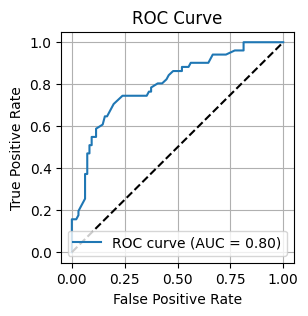

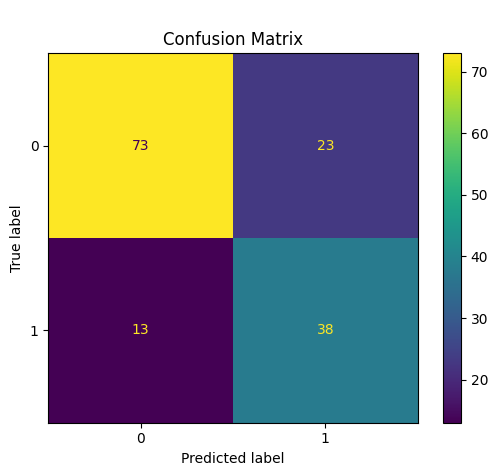



               precision    recall  f1-score   support

           0       0.85      0.76      0.80        96
           1       0.62      0.75      0.68        51

    accuracy                           0.76       147
   macro avg       0.74      0.75      0.74       147
weighted avg       0.77      0.76      0.76       147



In [54]:
ranfor_=RandomForestClassifier(n_estimators=100, min_samples_split=2, min_samples_leaf=1, max_features="sqrt", random_state=42)
ranfor_.fit(X_train_1_no_flags, y_train_fin)
y_pred_ranfor_orig=ranfor_.predict(X_test_1_no_flags)

#dibujo la curva ROC-AUC para Random Forest (sin flags)
y_proba = ranfor_.predict_proba(X_test_1_no_flags)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

print(f'\n{under}{bold}MÉTRICAS DE EVALUACIÓN PARA RANDOM FOREST (SIN FLAGS) CON CRITERIOS INICIALES{reset}\n\n')
plt.figure(figsize=(3,3))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

#dibujo la matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ranfor_orig)
print('\n')
plt.title("\nConfusion Matrix")
plt.grid(False)
plt.show()

#muestro las métricas
print('\n\n', classification_report(y_test, y_pred_ranfor_orig))

###**<font color='green'>6.5.3. XGBoost (con flags)**


MÉTRICAS DE EVALUACIÓN PARA XGBOOST




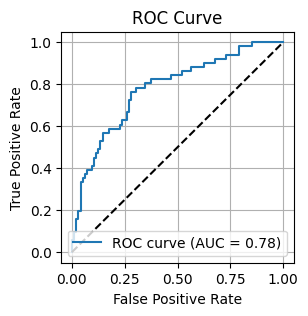

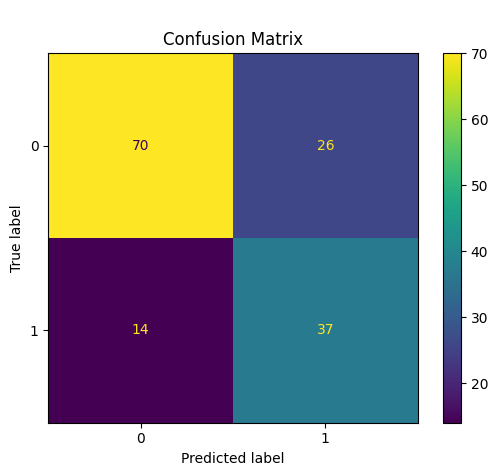



               precision    recall  f1-score   support

           0       0.83      0.73      0.78        96
           1       0.59      0.73      0.65        51

    accuracy                           0.73       147
   macro avg       0.71      0.73      0.71       147
weighted avg       0.75      0.73      0.73       147



In [55]:
#dibujo la curva ROC-AUC para XGBoost
y_proba = xgb_opt.predict_proba(X_test_1)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

print(f'\n{under}{bold}MÉTRICAS DE EVALUACIÓN PARA XGBOOST{reset}\n\n')
plt.figure(figsize=(3,3))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

#dibujo la matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)
print('\n')
plt.title("\nConfusion Matrix")
plt.grid(False)
plt.show()

#muestro las métricas
print('\n\n', classification_report(y_test, y_pred_xgb))

###**<font color='green'>6.5.4. Conclusión**

Viendo la evaluación de los 3 modelos, nos quedaríamos con el modelo de **Random Forest, entrenado sin las variables flags**, pero con el modelo que se entreno primero, que presenta un ROC-AUC de 0.80 y el recall para las dos categorias posibles es de 0.76 y 0.75, lo que es el más elevado y más equilibrado, ya que nos interesa trabajar con el que nos de un mayor acierto para aquellos casos que sí que tienen diabetes.

No obstante, probaremos con la variación del umbral en los 3 casos que estabamos barajando.

##**<font color='green'>6.6. Mejorar con threshold**

###**<font color='green'>6.6.1. Random Forest (con flags)**

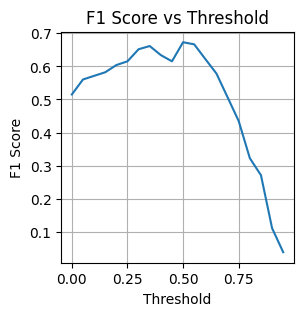

In [56]:
#Paso 1: Obtenemos probabilidades de las predicciones con el modelo
#en realidad ya la teniamos calculada del paso anterior
y_proba = ranfor_flags_opt.predict_proba(X_test_1)[:, 1]

#Paso 2: Probamos diferentes thresholds
thresholds = np.arange(0.0, 1.0, 0.05)
f1_scores = []

for t in thresholds:
    y_pred_thresh = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    f1_scores.append(f1)

plt.figure(figsize=(3,3))
plt.plot(thresholds, f1_scores)
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold')
plt.grid()
plt.show()

Evaluación con threshold = 0.33


f1-score:  0.6666666666666666

               precision    recall  f1-score   support

           0       0.89      0.61      0.73        96
           1       0.54      0.86      0.67        51

    accuracy                           0.70       147
   macro avg       0.72      0.74      0.70       147
weighted avg       0.77      0.70      0.71       147



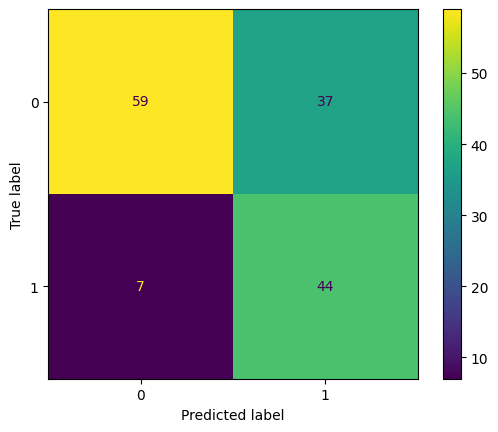

Evaluación con threshold = 0.32


f1-score:  0.6616541353383458

               precision    recall  f1-score   support

           0       0.89      0.60      0.72        96
           1       0.54      0.86      0.66        51

    accuracy                           0.69       147
   macro avg       0.71      0.73      0.69       147
weighted avg       0.77      0.69      0.70       147



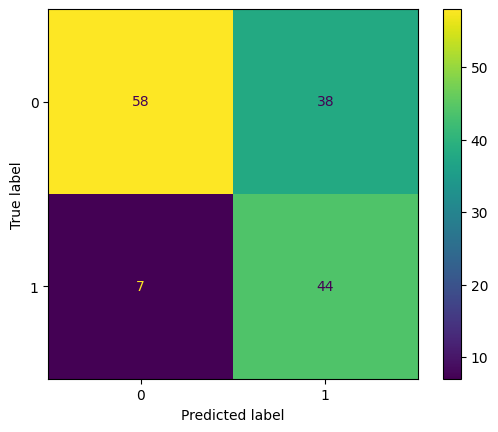

Evaluación con threshold = 0.36


f1-score:  0.6511627906976745

               precision    recall  f1-score   support

           0       0.87      0.62      0.73        96
           1       0.54      0.82      0.65        51

    accuracy                           0.69       147
   macro avg       0.70      0.72      0.69       147
weighted avg       0.75      0.69      0.70       147



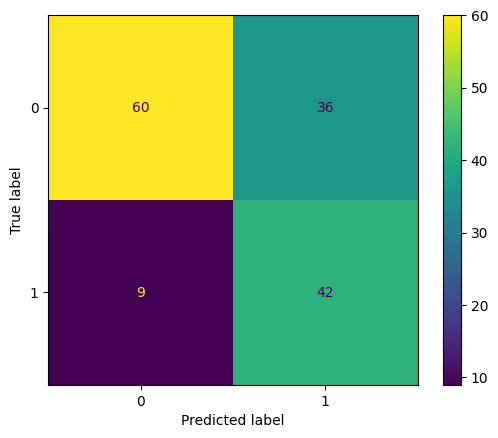

In [57]:
#Paso 3: Aplicamos el mejor threshold (podemos probar varios valores)
#segun la gráfica, parece que el f1-score se maximiza para el threshold de 0.50
#pero tambien hay otro pico, hacia el 0,33.
#Probamos valores alrededor de 0.33, a ver si encontramos el que maximiza a f1
best_thresh = 0.33
print(f'{under}{bold}Evaluación con threshold = {best_thresh}{reset}\n')
y_pred_thresh = (y_proba >= best_thresh).astype(int)

#Evaluamos con nuevo threshold
print('\nf1-score: ', f1_score(y_test, y_pred_thresh))
print('\n', classification_report(y_test, y_pred_thresh))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_thresh)
plt.show()


#Probamos 0.32
best_thresh = 0.32
print(f'{under}{bold}Evaluación con threshold = {best_thresh}{reset}\n')
y_pred_thresh = (y_proba >= best_thresh).astype(int)

#Evaluamos con nuevo threshold
print('\nf1-score: ', f1_score(y_test, y_pred_thresh))
print('\n', classification_report(y_test, y_pred_thresh))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_thresh)
plt.show()


#Probamos 0.36
best_thresh = 0.36
print(f'{under}{bold}Evaluación con threshold = {best_thresh}{reset}\n')
y_pred_thresh = (y_proba >= best_thresh).astype(int)

#Evaluamos con nuevo threshold
print('\nf1-score: ', f1_score(y_test, y_pred_thresh))
print('\n', classification_report(y_test, y_pred_thresh))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_thresh)
plt.show()

Parece que en el primer pico, que es lo que hemos visto ahora, la clasificación de la clase 1, tiene diabetes, es muy buena, yendonos a un recall de más de un 85% en el punto máximo. En el otro pico de la gráfica que hicimos, parece que nos encontramos con el modelo con el valor máximo para f1 score en un umbral del 50% (el modelo actual), en donde llegamos a un recall del 83% para la clase 0 (no tener diabetes).

Vamos a ver que ocurre en donde se da el punto de inflexión entre los dos picos:

Evaluación con threshold = 0.4


f1-score:  0.6341463414634146

               precision    recall  f1-score   support

           0       0.84      0.66      0.74        96
           1       0.54      0.76      0.63        51

    accuracy                           0.69       147
   macro avg       0.69      0.71      0.69       147
weighted avg       0.74      0.69      0.70       147



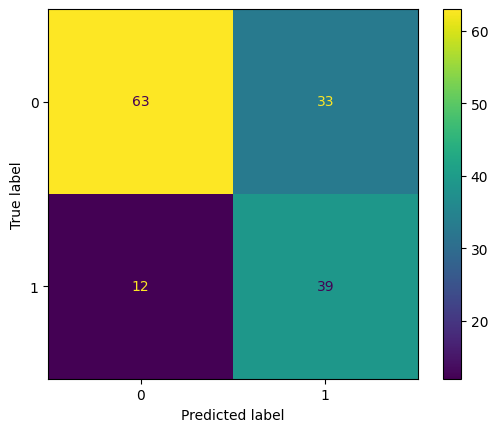

Evaluación con threshold = 0.44


f1-score:  0.6218487394957983

               precision    recall  f1-score   support

           0       0.82      0.68      0.74        96
           1       0.54      0.73      0.62        51

    accuracy                           0.69       147
   macro avg       0.68      0.70      0.68       147
weighted avg       0.73      0.69      0.70       147



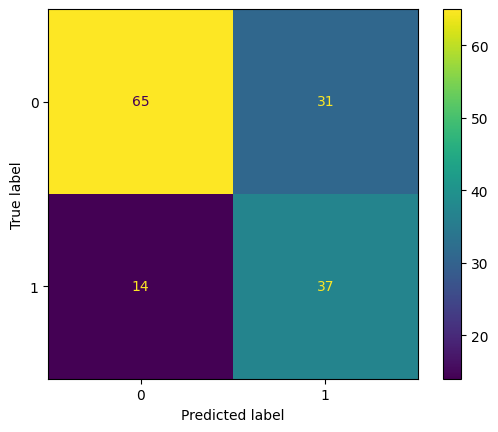

Evaluación con threshold = 0.47


f1-score:  0.6260869565217392

               precision    recall  f1-score   support

           0       0.82      0.71      0.76        96
           1       0.56      0.71      0.63        51

    accuracy                           0.71       147
   macro avg       0.69      0.71      0.69       147
weighted avg       0.73      0.71      0.71       147



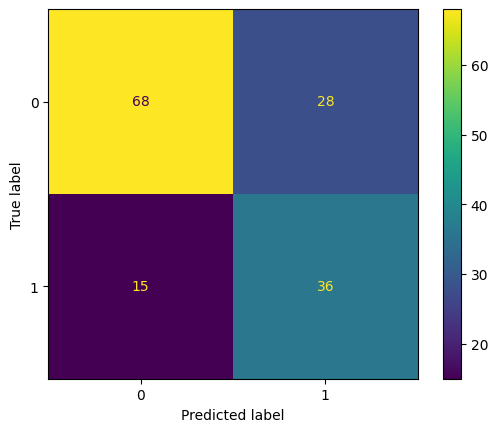

In [58]:
#Parece que el punto de inflexion esta alrededor del 0.44
best_thresh = 0.40
print(f'{under}{bold}Evaluación con threshold = {best_thresh}{reset}\n')
y_pred_thresh = (y_proba >= best_thresh).astype(int)

#Evaluamos con nuevo threshold
print('\nf1-score: ', f1_score(y_test, y_pred_thresh))
print('\n', classification_report(y_test, y_pred_thresh))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_thresh)
plt.show()


#Probamos 0.44
best_thresh = 0.44
print(f'{under}{bold}Evaluación con threshold = {best_thresh}{reset}\n')
y_pred_thresh = (y_proba >= best_thresh).astype(int)

#Evaluamos con nuevo threshold
print('\nf1-score: ', f1_score(y_test, y_pred_thresh))
print('\n', classification_report(y_test, y_pred_thresh))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_thresh)
plt.show()


#Probamos 0.47
best_thresh = 0.47
print(f'{under}{bold}Evaluación con threshold = {best_thresh}{reset}\n')
y_pred_thresh = (y_proba >= best_thresh).astype(int)

#Evaluamos con nuevo threshold
print('\nf1-score: ', f1_score(y_test, y_pred_thresh))
print('\n', classification_report(y_test, y_pred_thresh))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_thresh)
plt.show()

Hemos visto que entre un pico y el otro de la gráfica, lo que va cambiando es el recall de las clases, pasando de un recall de 0.86 para la clase 1 a un recall de 0.83 para la clase 0.

Como lo que más nos interesa es una buean predicción de la clase 1, lo suyo sería tomar un threshold más cercano a la primera punta del gráfico. Pero no podemos olvidar que en detrimento, el recall de la clase 0 en ese caso seria de un 0.6, lo que acaba haciendo que del total de las predicciones en la clase 1, tan solo un 54% serían correctas.

En función de las medidas que se tomarán con las personas que las predicciones den que tienen (o tendran) diabetes, los costes pueden ser muy elevados si tan solo el 50% de las personas realmente lo son. De ser así, podría ser más conveniente encontrar un valor para el umbral que permita tener un recall para la clase 1 del 75-80%, con una precisión de la clase 1, cercana al 65%, para encontrar un punto un poco más equlibrado. Pero si el coste no fuera un problema, obviemanete elegiriamos la opción con más recall posible, con el umbral de 0.33.

Viendo los diferentes valores que hemos ido probando para el umbral, es obvio que estaríamos buscando un unbral entre 0.33 y 0.44, donde el recall de la clase 1 es mayor que el de la clase 0. Pero vemos que en el caso del umbral de 0,47, donde el recall de la clase 1 se situa al mismo nivel que el de la clase 0, la precision de la clase 1 tan solo se situa en el 56%, lo que sigue haciendo que ni siquiera un 60% de las predicciones en clase 1 tenga realmente diabetes.

No es hasta un threshold del 0.486 que conseguimos una precision en la predicción de la clase 1 del 0.61, pero tan solo nos clasificaria bien el 69% de los casos reales con diabetes, con f1-score de 0.65 (ver a continuación). Para eso, **nos quedariamos con el threshold del 0.5 en este caso**, que ya nos daba un recall para la clase 1 de 0.69 (igual), pero tenia un recall para la clase 0 de 0.83 y la precision de las predicciones de la clase 1 se alzaban hasta un 0.69.

Evaluación con threshold = 0.486


f1-score:  0.6481481481481481

               precision    recall  f1-score   support

           0       0.82      0.77      0.80        96
           1       0.61      0.69      0.65        51

    accuracy                           0.74       147
   macro avg       0.72      0.73      0.72       147
weighted avg       0.75      0.74      0.74       147



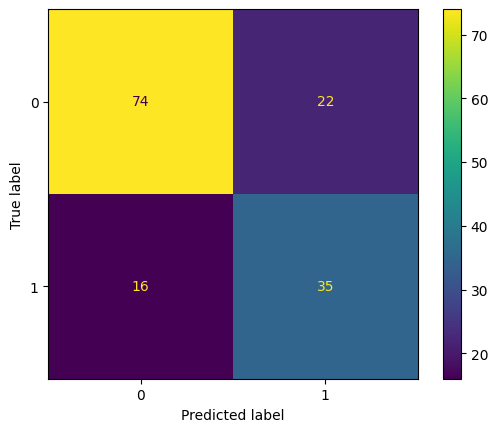

In [59]:
best_thresh = 0.486
print(f'{under}{bold}Evaluación con threshold = {best_thresh}{reset}\n')
y_pred_thresh = (y_proba >= best_thresh).astype(int)

#Evaluamos con nuevo threshold
print('\nf1-score: ', f1_score(y_test, y_pred_thresh))
print('\n', classification_report(y_test, y_pred_thresh))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_thresh)
plt.show()

###**<font color='green'>6.6.2. Random Forest (sin flags)**

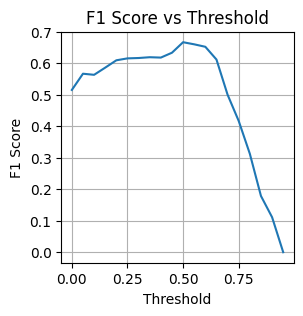

In [60]:
#Paso 1: Obtenemos probabilidades de las predicciones con el modelo
#en realidad ya la teniamos calculada del paso anterior
y_proba = ranfor_.predict_proba(X_test_1_no_flags)[:, 1]

#Paso 2: Probamos diferentes thresholds
thresholds = np.arange(0.0, 1.0, 0.05)
f1_scores = []

for t in thresholds:
    y_pred_thresh = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    f1_scores.append(f1)

plt.figure(figsize=(3,3))
plt.plot(thresholds, f1_scores)
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold')
plt.grid()
plt.show()


f1-score:  0.6333333333333333

               precision    recall  f1-score   support

           0       0.83      0.68      0.75        96
           1       0.55      0.75      0.63        51

    accuracy                           0.70       147
   macro avg       0.69      0.71      0.69       147
weighted avg       0.74      0.70      0.71       147



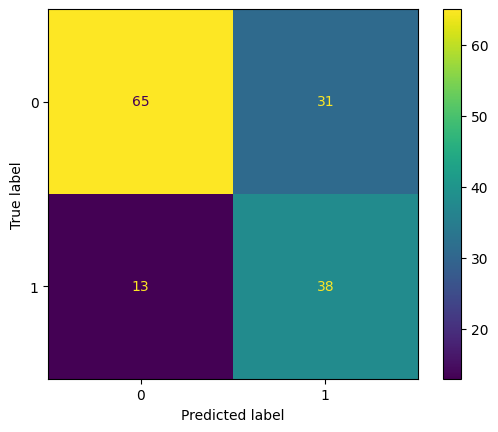


f1-score:  0.66

               precision    recall  f1-score   support

           0       0.82      0.83      0.82        96
           1       0.67      0.65      0.66        51

    accuracy                           0.77       147
   macro avg       0.74      0.74      0.74       147
weighted avg       0.77      0.77      0.77       147



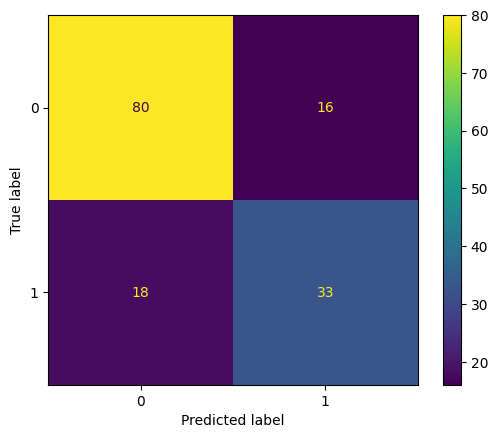

In [61]:
#Paso 3: Aplicamos el mejor threshold (podemos probar varios valores)
#segun la gráfica, parece que el f1-score se maximiza justo en 0.5
#probemos con un poco menos y un poco más de ubral a ver si vemos variaciones

#probamos con 0.45
best_thresh = 0.45
y_pred_thresh = (y_proba >= best_thresh).astype(int)

#Evaluamos con nuevo threshold
print('\nf1-score: ', f1_score(y_test, y_pred_thresh))
print('\n', classification_report(y_test, y_pred_thresh))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_thresh)
plt.show()


#probamos con 0.55
best_thresh = 0.55
y_pred_thresh = (y_proba >= best_thresh).astype(int)

#Evaluamos con nuevo threshold
print('\nf1-score: ', f1_score(y_test, y_pred_thresh))
print('\n', classification_report(y_test, y_pred_thresh))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_thresh)
plt.show()

Con los nuevos umbrales, vemos que aunque alguno de los recall mejora. Si mejora el recall de la clase 0 y empeora el de la clase 1, no nos interesa. Pero si mejorara la detección de la clase 1, podríamos considerarlo, pero tampoco lo hace.

**Por lo que dejaremos el umbral al 50%, tal y como estaba inicialmente**

###**<font color='green'>6.6.3. XGBoost (con flags)**

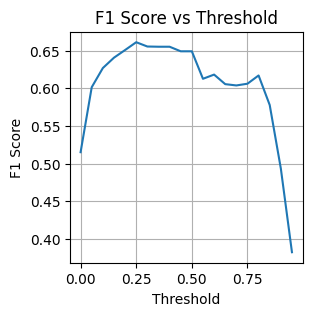

In [62]:
#Paso 1: Obtenemos probabilidades de las predicciones con el modelo
#en realidad ya la teniamos calculada del paso anterior
y_proba = xgb_opt.predict_proba(X_test_1)[:, 1]

#Paso 2: Probamos diferentes thresholds
thresholds = np.arange(0.0, 1.0, 0.05)
f1_scores = []

for t in thresholds:
    y_pred_thresh = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    f1_scores.append(f1)

plt.figure(figsize=(3,3))
plt.plot(thresholds, f1_scores)
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold')
plt.grid()
plt.show()

Evaluación con threshold = 0.25


f1-score:  0.6611570247933884

               precision    recall  f1-score   support

           0       0.86      0.69      0.76        96
           1       0.57      0.78      0.66        51

    accuracy                           0.72       147
   macro avg       0.71      0.74      0.71       147
weighted avg       0.76      0.72      0.73       147



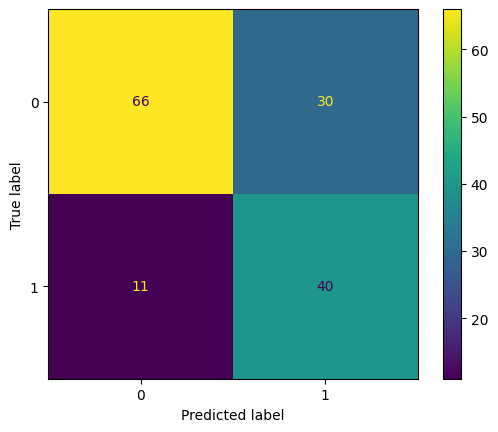

In [63]:
#Paso 3: Aplicamos el mejor threshold (podemos probar varios valores)
#segun la gráfica, parece que el f1-score se maximiza para el threshold de 0.25
#probamos con 0.25
best_thresh = 0.25
print(f'{under}{bold}Evaluación con threshold = {best_thresh}{reset}\n')
y_pred_thresh = (y_proba >= best_thresh).astype(int)

#Evaluamos con nuevo threshold
print('\nf1-score: ', f1_score(y_test, y_pred_thresh))
print('\n', classification_report(y_test, y_pred_thresh))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_thresh)
plt.show()

Evaluación con threshold = 0.28


f1-score:  0.6554621848739496

               precision    recall  f1-score   support

           0       0.85      0.70      0.77        96
           1       0.57      0.76      0.66        51

    accuracy                           0.72       147
   macro avg       0.71      0.73      0.71       147
weighted avg       0.75      0.72      0.73       147



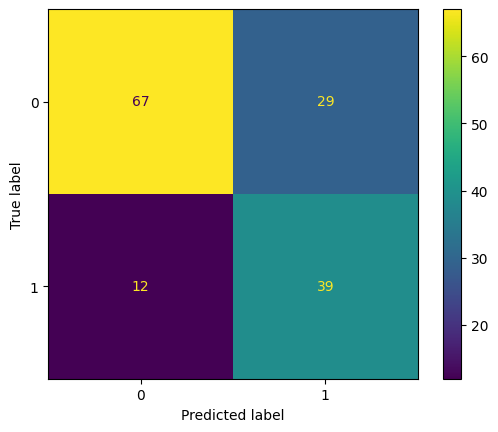

Evaluación con threshold = 0.38


f1-score:  0.6551724137931034

               precision    recall  f1-score   support

           0       0.84      0.72      0.78        96
           1       0.58      0.75      0.66        51

    accuracy                           0.73       147
   macro avg       0.71      0.73      0.72       147
weighted avg       0.75      0.73      0.73       147



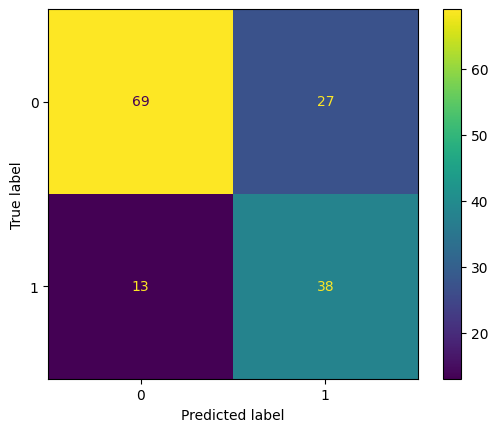

Evaluación con threshold = 0.45


f1-score:  0.6491228070175439

               precision    recall  f1-score   support

           0       0.83      0.73      0.78        96
           1       0.59      0.73      0.65        51

    accuracy                           0.73       147
   macro avg       0.71      0.73      0.71       147
weighted avg       0.75      0.73      0.73       147



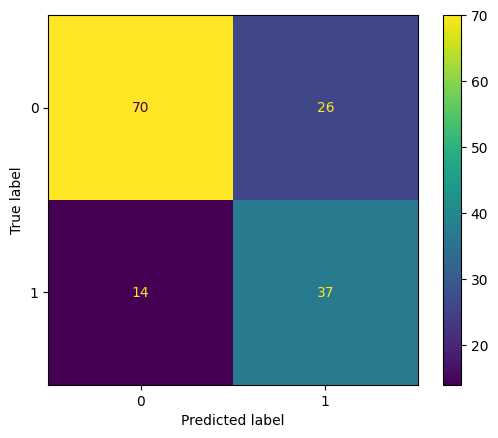

In [64]:
#Probaremos valores entre 0.25 y 0.5 intentando llegar a una precision de 0.6
best_thresh = 0.28
print(f'{under}{bold}Evaluación con threshold = {best_thresh}{reset}\n')
y_pred_thresh = (y_proba >= best_thresh).astype(int)

#Evaluamos con nuevo threshold
print('\nf1-score: ', f1_score(y_test, y_pred_thresh))
print('\n', classification_report(y_test, y_pred_thresh))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_thresh)
plt.show()


best_thresh = 0.38
print(f'{under}{bold}Evaluación con threshold = {best_thresh}{reset}\n')
y_pred_thresh = (y_proba >= best_thresh).astype(int)

#Evaluamos con nuevo threshold
print('\nf1-score: ', f1_score(y_test, y_pred_thresh))
print('\n', classification_report(y_test, y_pred_thresh))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_thresh)
plt.show()



best_thresh = 0.45
print(f'{under}{bold}Evaluación con threshold = {best_thresh}{reset}\n')
y_pred_thresh = (y_proba >= best_thresh).astype(int)

#Evaluamos con nuevo threshold
print('\nf1-score: ', f1_score(y_test, y_pred_thresh))
print('\n', classification_report(y_test, y_pred_thresh))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_thresh)
plt.show()

En este caso vemos que si maximizamos el f1 score, obtenemos un recall para la clase 1 de 0.78, en detrimento de la clase 0 que obtiene un recall de 0.69, con una precisión del 57%. Tomando posibles valores de f1, acercándonos a un umbral de 0.5, vemos que no llegamos a una precisión del 60%, lo que nos da como **mejor opción la que ya teníamos del umbral en 0.5**

###**<font color='green'>6.6.4. Conclusión**



Tras realizar la optimización de parámetros e intentar obtener unas mejores predcciones modificando el umbral, vemos en en ninguno de los 3 casos obteniamos mejores resultados.

Por tanto, tal y como habíamos concluido tras realizar las métricas correspondientes después de optimizar los parámetros, nos quedaríamos con el **Random Forest sin usar las variables flags como mejor modelo**.  

##**<font color='green'>6.7. Guardado del modelo**

In [65]:
import joblib

#Recordatorio de Random Forest entrenado SIN flags, antes de optimizar
#ranfor_=RandomForestClassifier(n_estimators=100, min_samples_split=2, min_samples_leaf=1, max_features="sqrt", random_state=42)
#ranfor_.fit(X_train_1_no_flags, y_train_fin)

#guardo el modelo en un archivo
joblib.dump(ranfor_, "../models/ranfor_no_flags_model.pkl")



['../models/ranfor_no_flags_model.pkl']